# Group 2

# Project: Hakiki Hire 

## Group Members

- Briannah Chelangat
- Christopher Kariuki
- Melisa Achieng
- Cleopas Karanja
- Alex Kinyua

---

## 1. Business Understanding

Kenyan job seekers often have limited ways to verify whether a vacancy is genuine before submitting applications, paying recruitment fees, or sharing personal information and identification documents. Fraudulent recruitment schemes can exploit this information gap by impersonating employers, agencies, or overseas recruiters.

Enforcement is frequently reactive because suspicious agencies or advertisements may only be investigated after complaints have been reported. The risks are especially serious for overseas recruitment opportunities, where victims may face financial losses, document misuse, or other forms of harm beyond the initial application process.

Hakiki Hire is designed as a decision-support system that helps identify patterns associated with legitimate, suspicious, and fraudulent job advertisements. The system provides risk signals to support further review and verification; it does not make legal determinations or officially classify a posting as fraudulent.

## 2. Data Understanding

No publicly available Kenyan job-advertisement dataset with verified fraud labels was identified during this project. This finding shaped the overall data strategy and explains the use of multiple source groups, including synthetic data, to support analysis and model development.

**EMSCAD** is the only source used in this project that contains verified fraud labels. It provides examples of legitimate and fraudulent recruitment advertisements, making it valuable for supervised learning. However, it is an international dataset and does not fully represent recruitment patterns that are specific to Kenya.

**The five Kenyan job-board datasets** provide locally relevant job advertisements, salary formats, recruitment language, and posting conventions. These records improve coverage of the Kenyan labour market but do not contain verified fraud labels. To avoid introducing unsupported assumptions, these records remain unlabelled unless a trustworthy label source is available.

**The synthetic datasets** were created to represent Kenya-specific scam patterns that are not available in any verified labelled public source. Synthetic records are clearly tagged, kept separate from real data through provenance tracking, and used to supplement rather than replace real-world observations.

The preparation label scheme is:

- `0`: Legitimate
- `1`: Suspicious
- `2`: Fraudulent

The original `is_fraud` label is retained for auditing and analysis, while downstream modelling may derive a binary risk target when required without overwriting the source label.


## Data-preparation pipeline (execution order)

This notebook is written to run top to bottom from a fresh kernel. Every step only uses objects created by the steps above it, and `final_df` is created **once** (Part 12) and then only cleaned.

| Part | Step |
| --- | --- |
| 1 | Project setup: imports, seeds, configuration, helper functions |
| 2 | Load all source datasets |
| 3 | Initial dataset inspection |
| 4 | Standardize column names |
| 5 | Clean string / text fields |
| 6 | Handle missing values |
| 7 | Normalize categorical values |
| 8 | Convert data types and validate labels |
| 9 | Parse structured fields (salary, email) |
| 10 | Source-specific cleaning of the two synthetic files |
| 11 | Standardize every source into the shared schema |
| 12 | Combine datasets and check labels |
| 13 | Exact duplicate removal |
| 14 | Normalized-text duplicate (fingerprint) removal |
| 15 | Final data-quality checks |
| 16 | Leakage and feature-preparation note |
| 17 | Canonical dataset for EDA and modelling (`eda_df`) |
| 18 | Export |
| 19 | Final automated check |

Data preparation ends at Part 19. **EDA and Modelling are not a separate notebook** -- they continue directly below, in this same notebook, as further parts (starting at Part 20), reading `eda_df` and `final_df` from memory rather than re-loading the exported CSV.

## Part 1: Project setup

Import the libraries, set the reproducible random seed, define configuration values, and define the shared schema before loading data.

In [1]:
import hashlib
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [2]:
DATA_DIR = Path(".")

SOURCE_FILES = {
    "Fake Job Postings":        DATA_DIR / "fake_job_postings.csv",
    "Fuzu Kenya":               DATA_DIR / "fuzu_kenya_jobs.csv",
    "PigiaMe Kenya":            DATA_DIR / "pigiame_jobs_full.csv",
    "Corporate Staffing Kenya": DATA_DIR / "corporatestaffing_jobs_full.csv",
    "BrighterMonday Kenya":     DATA_DIR / "brightermonday_kenya_jobs.csv",
    "JobWeb Kenya":             DATA_DIR / "jobwebkenya_jobs_full.csv",
    "Synthetic 40k":            DATA_DIR / "synthetic_40k.csv",
    "Synthetic Augmentation":   DATA_DIR / "synthetic_augmentation_postings.csv",
}

SCHEMA = [
    "title", "company", "company_profile", "location", "industry_category", "work_type",
    "salary_range", "experience_level", "min_qualification",
    "description", "requirements", "source_url", "source_platform",
    "is_fraud", "data_source",
]

DEDUP_COLUMNS = ["title", "company", "location", "description", "company_profile"]

# Source groups used by the label-integrity checks (Parts 12, 14, 18, 19)
EMSCAD_PLATFORM = "Fake Job Postings Dataset"
JOB_BOARD_SOURCES = ["Fuzu Kenya", "PigiaMe Kenya", "Corporate Staffing Kenya",
                     "BrighterMonday Kenya", "JobWeb Kenya"]

# Labels: 
class_names = {0: "Legitimate", 1: "Suspicious", 2: "Fraudulent"}

# Raw labels 
EMSCAD_LABEL_MAP = {0: 0, 1: 2}                
SYNTHETIC_LABEL_MAP = {0: 0, 1: 1, 2: 2}
# Salary parsing 
USD_TO_KES = 130  
salary_pattern = re.compile(r"^(KES|USD)\s*([\d,]+)\s*/\s*(\w+)$", flags=re.IGNORECASE)

# Email validation
email_pattern = re.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")

# Work-type spelling variants
WORK_TYPE_MAP = {
    "full time": "Full-time", "full-time": "Full-time", "full_time": "Full-time", "fulltime": "Full-time",
    "part time": "Part-time", "part-time": "Part-time", "part_time": "Part-time", "parttime": "Part-time",
}
EXPORT_FILE = "merged_job_scam_3class.csv"

In [3]:
def get_datasets():
    """Current version of every source frame.

    Read from the globals on every call so a frame that was re-assigned
    (for example df1 after dropping columns) is never a stale copy.
    """
    return {
        "Fake Job Postings":        df_fake,
        "Fuzu Kenya":               df_fuzu,
        "PigiaMe Kenya":            df_pigia,
        "Corporate Staffing Kenya": df_corp,
        "BrighterMonday Kenya":     df_bm,
        "JobWeb Kenya":             df_jobweb,
        "Synthetic 40k":            df1,
        "Synthetic Augmentation":   df2,
    }


def text_columns(frame):
    """Names of the columns that hold text (object / string dtypes)."""
    return [
        col for col in frame.columns
        if frame[col].dtype == "object" or pd.api.types.is_string_dtype(frame[col].dtype)
    ]


def trim_text_columns(frame):
    """Strip leading/trailing whitespace in every text column, in place.

    Returns the number of values per column that still have edge whitespace.
    """
    for col in text_columns(frame):
        frame[col] = frame[col].astype("string").str.strip()
    return {col: int((frame[col] != frame[col].str.strip()).sum()) for col in text_columns(frame)}


def normalize_work_type(series):
    """Collapse spelling variants of Full-time / Part-time; leave other values untouched."""
    if not (series.dtype == "object" or pd.api.types.is_string_dtype(series.dtype)):
        return series
    trimmed = series.astype("string").str.strip()
    mapped = trimmed.str.lower().map(WORK_TYPE_MAP)
    return mapped.fillna(trimmed).astype("string")


def parse_salary(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, np.nan])
    m = salary_pattern.match(str(value).strip())
    if not m:
        return pd.Series([np.nan, np.nan, np.nan])
    currency, amount, period = m.groups()
    return pd.Series([currency.upper(), float(amount.replace(',', '')), period.lower()])


def assert_no_label_transfer(frame, stage):
    """Real rows may only carry the label their own source supplied.

    Kenyan job-board rows have no source label, so `is_fraud` must be NaN.
    EMSCAD only has Legitimate (0) and Fraudulent (2); a Suspicious (1) on an
    EMSCAD row could only have come from a synthetic row.
    """
    job_board = frame["source_platform"].isin(JOB_BOARD_SOURCES)
    emscad = frame["source_platform"] == EMSCAD_PLATFORM
    assert frame.loc[job_board, "is_fraud"].isna().all(), (
        f"[{stage}] a label was transferred onto an unlabelled job-board row"
    )
    assert set(frame.loc[emscad, "is_fraud"].dropna().unique()) <= {0, 2}, (
        f"[{stage}] an EMSCAD row carries a label EMSCAD cannot produce"
    )
    print(f"[{stage}] PASS no synthetic label on real rows "
          f"(job-board rows unlabelled: {int(job_board.sum()):,}; "
          f"EMSCAD labels only 0/2: {int(emscad.sum()):,} rows)")


def assert_no_fraud_risk(stage, frames):
    """`fraud_risk` is a modelling-stage target and must not exist during preparation."""
    for name, frame in frames.items():
        assert "fraud_risk" not in frame.columns, f"[{stage}] fraud_risk found in {name}"
    print(f"[{stage}] PASS fraud_risk absent from: {', '.join(frames)}")


## Part 2: Load all source datasets

Every raw file used by the project is loaded here **once**. Later cells clean these objects in place or re-assign them; nothing reads a raw CSV again.

Six original datasets: EMSCAD (`fake_job_postings.csv`) and five Kenyan job boards. Two synthetic files: `synthetic_40k.csv` (`df1`, raw labels 0/1/2 = Legitimate/Suspicious/Fraudulent) and `synthetic_augmentation_postings.csv` (`df2`).
Both synthetic files are merged.

In [4]:
# Six original datasets
df_fake   = pd.read_csv(SOURCE_FILES["Fake Job Postings"])
df_fuzu   = pd.read_csv(SOURCE_FILES["Fuzu Kenya"])
df_pigia  = pd.read_csv(SOURCE_FILES["PigiaMe Kenya"])
df_corp   = pd.read_csv(SOURCE_FILES["Corporate Staffing Kenya"])
df_bm     = pd.read_csv(SOURCE_FILES["BrighterMonday Kenya"])
df_jobweb = pd.read_csv(SOURCE_FILES["JobWeb Kenya"])

# Synthetic datasets

df1 = pd.read_csv(SOURCE_FILES["Synthetic 40k"])
df2 = pd.read_csv(SOURCE_FILES["Synthetic Augmentation"])

for name, frame in get_datasets().items():
    print(f"{name}")
    print(f"   rows: {frame.shape[0]:,} | columns: {frame.shape[1]}")
    print(f"   column names: {frame.columns.tolist()}")

Fake Job Postings
   rows: 17,880 | columns: 18
   column names: ['    job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']
Fuzu Kenya
   rows: 666 | columns: 7
   column names: ['title', 'company', 'location', 'salary_range', 'tags', 'description', 'source_url']
PigiaMe Kenya
   rows: 1,500 | columns: 8
   column names: ['title', 'company', 'work_type', 'location', 'salary_range', 'posted', 'description', 'source_url']
Corporate Staffing Kenya
   rows: 3,988 | columns: 7
   column names: ['title', 'industry', 'salary_range', 'location', 'deadline', 'description', 'source_url']
BrighterMonday Kenya
   rows: 1,964 | columns: 13
   column names: ['title', 'company', 'category', 'location', 'work_type', 'salary_range', 'min_qualification', 'experience_level', 'experie

## Part 3: Initial dataset inspection

The starting state of every source before anything is modified: structure, first rows, summary statistics, missing values and exact duplicates.

In [5]:
for name, frame in get_datasets().items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    print("Shape:", frame.shape)
    print()
    frame.info()
    print("\nFirst rows:")
    display(frame.head())
    print("\nDescriptive statistics:")
    display(frame.describe(include="all").T)
    print("\nMissing values per column:")
    display(frame.isna().sum().to_frame("missing_count"))
    print("Fully-identical duplicate rows:", frame.duplicated().sum())
    print()

Fake Job Postings
Shape: (17880, 18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0       job_id           17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry       

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,17880.0,NaN,NaN,NaN,8940.5,5161.655742,1.0,4470.75,8940.5,13410.25,17880.0
title,17880,11231,English Teacher Abroad,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,17534,3105,"GB, LND, London",718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,6333,1337,Sales,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_range,2868,874,0-0,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_profile,14572,1709,We help teachers get safe &amp; secure jobs ab...,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,17879,14801,"Play with kids, get paid for it Love travel? J...",379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requirements,15184,11967,University degree required. TEFL / TESOL / CEL...,410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefits,10668,6204,See job description,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
telecommuting,17880.0,NaN,NaN,NaN,0.042897,0.202631,0.0,0.0,0.0,0.0,1.0



Missing values per column:


...


Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
posting_id,5000,5000,SYN-000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,5000,12,Customer Service Agent,464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,5000,2534,Salary is commensurate with experience and wil...,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,5000,3905,Not disclosed,742,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agency,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,5000,9,Nyeri,598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,5000,3,Full-time,1704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email,4258,4258,browningjason@hamilton.com,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values per column:


,missing_count
posting_id,0
title,0
description,0
company,0
agency,5000
location,0
salary,5000
employment_type,0
email,742
source,5000


Fully-identical duplicate rows: 0



### 3.1 Labeling


In [6]:
print("EMSCAD 'fraudulent' (0 = legitimate, 1 = fraudulent):")
print(df_fake["fraudulent"].value_counts(dropna=False).sort_index())

print("\nsynthetic_40k 'is_fraud':")
print(df1["is_fraud"].value_counts(dropna=False).sort_index())

print("\nsynthetic_augmentation 'is_fraud':")
print(df2["is_fraud"].value_counts(dropna=False).sort_index())

print("\nKenyan job boards, label column present?")
for name, frame in [("Fuzu Kenya", df_fuzu), ("PigiaMe Kenya", df_pigia),
                    ("Corporate Staffing Kenya", df_corp),
                    ("BrighterMonday Kenya", df_bm), ("JobWeb Kenya", df_jobweb)]:
    print(f"   {name}: {any(col in frame.columns for col in ('is_fraud', 'fraudulent'))}")

EMSCAD 'fraudulent' (0 = legitimate, 1 = fraudulent):
fraudulent
0    17014
1      866
Name: count, dtype: int64

synthetic_40k 'is_fraud':
is_fraud
0    22857
1    11429
2     5714
Name: count, dtype: int64

synthetic_augmentation 'is_fraud':
is_fraud
0    4258
1     535
2     207
Name: count, dtype: int64

Kenyan job boards, label column present?
   Fuzu Kenya: False
   PigiaMe Kenya: False
   Corporate Staffing Kenya: False
   BrighterMonday Kenya: False
   JobWeb Kenya: False


## Part 4: Standardize column names

The dataset is standardized because it is built from very different sources: EMSCAD, five Kenyan job boards and two synthetic files. Each has its own column names, missing fields and labelling scheme, so they can only be stacked into one table once they share a common schema.

In [7]:
for frame in get_datasets().values():
    frame.columns = (
        frame.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

for name, frame in get_datasets().items():
    print(f"\n{name}")
    print(frame.columns.tolist())


Fake Job Postings
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Fuzu Kenya
['title', 'company', 'location', 'salary_range', 'tags', 'description', 'source_url']

PigiaMe Kenya
['title', 'company', 'work_type', 'location', 'salary_range', 'posted', 'description', 'source_url']

Corporate Staffing Kenya
['title', 'industry', 'salary_range', 'location', 'deadline', 'description', 'source_url']

BrighterMonday Kenya
['title', 'company', 'category', 'location', 'work_type', 'salary_range', 'min_qualification', 'experience_level', 'experience_length', 'language_requirement', 'working_hours', 'description', 'source_url']

JobWeb Kenya
['title', 'company', 'location', 'state', 'job_type', 'job_category', 'closing_date', 'description', 'source_url']

Synthetic 40

## Part 5: Clean string / text fields

Leading and trailing whitespace is stripped from every text column of every source **before** any duplicate detection, so two copies of a posting that differ only by stray spaces are recognised as the same posting. The wording of titles and descriptions is not altered.

In [8]:
for name, frame in get_datasets().items():
    print(f"{name}: text columns -> {text_columns(frame)}")
    print("   remaining whitespace issues:", trim_text_columns(frame))

Fake Job Postings: text columns -> ['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
   remaining whitespace issues: {'title': 0, 'location': 0, 'department': 0, 'salary_range': 0, 'company_profile': 0, 'description': 0, 'requirements': 0, 'benefits': 0, 'employment_type': 0, 'required_experience': 0, 'required_education': 0, 'industry': 0, 'function': 0}
Fuzu Kenya: text columns -> ['title', 'company', 'location', 'tags', 'description', 'source_url']
   remaining whitespace issues: {'title': 0, 'company': 0, 'location': 0, 'tags': 0, 'description': 0, 'source_url': 0}
PigiaMe Kenya: text columns -> ['title', 'work_type', 'location', 'salary_range', 'posted', 'source_url']
   remaining whitespace issues: {'title': 0, 'work_type': 0, 'location': 0, 'salary_range': 0, 'posted': 0, 'source_url': 0}
Corporate Staffing Kenya: text columns ->

## Part 6: Handle missing values

### 6.1 `synthetic_40k.csv` (`df1`)

`source_url` is null in the local synthetic file and carries no modelling information there, so the cleaning step removes fully null columns.

In [9]:
missing_df1 = df1.isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing_df1.to_frame('missing_percent'))

fully_null_cols = missing_df1[missing_df1 == 100].index.tolist()
print('Fully-null columns to drop:', fully_null_cols)

df1 = df1.drop(columns=fully_null_cols)
print('Shape after dropping fully-null columns:', df1.shape)

,missing_percent
source_url,100.0
title,0.0
company,0.0
location,0.0
industry_category,0.0
work_type,0.0
salary_range,0.0
experience_level,0.0
min_qualification,0.0
description,0.0


Fully-null columns to drop: ['source_url']
Shape after dropping fully-null columns: (40000, 12)


### 6.2 `synthetic_augmentation_postings.csv` (`df2`)

"agency", "salary", and "source" are 100% null across all 5,000 rows and so they are dropped

"email" is missing for ~15% of rows. Rather than dropping those rows, a "has_email" flag is kept and the NaNs are filled with an explicit placeholder instead of silently left blank.

In [10]:
missing_df2 = df2.isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing_df2.to_frame('missing_percent'))

fully_null_cols_df2 = missing_df2[missing_df2 == 100].index.tolist()
print('Fully-null columns to drop:', fully_null_cols_df2)
df2 = df2.drop(columns=fully_null_cols_df2)

df2['has_email'] = df2['email'].notna()
df2['email'] = df2['email'].fillna('not_provided')

print('\nShape after cleanup:', df2.shape)
print(df2['has_email'].value_counts())

,missing_percent
agency,100.00
salary,100.00
source,100.00
email,14.84
posting_id,0.00
title,0.00
description,0.00
company,0.00
location,0.00
employment_type,0.00


Fully-null columns to drop: ['agency', 'salary', 'source']

Shape after cleanup: (5000, 12)
has_email
True     4258
False     742
Name: count, dtype: int64


## Part 7: Normalize categorical values

Spelling variants of the work type (`full time`, `Full_Time`, `part-time`, ...) are collapsed to one label per category **before** the sources are merged and before any distribution is calculated. Values that are not a known Full-time / Part-time variant are left exactly as they are.

In [11]:
work_type_targets = {
    "Fake Job Postings":    (df_fake,   "employment_type"),
    "PigiaMe Kenya":        (df_pigia,  "work_type"),
    "BrighterMonday Kenya": (df_bm,     "work_type"),
    "JobWeb Kenya":         (df_jobweb, "job_type"),
    "Synthetic 40k":        (df1,       "work_type"),
    "Synthetic Augmentation": (df2,     "employment_type"),
}

for name, (frame, column) in work_type_targets.items():
    if column not in frame.columns:
        print(f"{name}: no '{column}' column, skipped")
        continue
    values_before = sorted(frame[column].dropna().unique())
    frame[column] = normalize_work_type(frame[column])
    values_after = sorted(frame[column].dropna().unique())
    print(f"{name} [{column}]")
    print("   before:", values_before)
    print("   after: ", values_after)

Fake Job Postings [employment_type]
   before: ['Contract', 'Full-time', 'Other', 'Part-time', 'Temporary']
   after:  ['Contract', 'Full-time', 'Other', 'Part-time', 'Temporary']
PigiaMe Kenya [work_type]
   before: ['Contract', 'Full time', 'Part time']
   after:  ['Contract', 'Full-time', 'Part-time']
BrighterMonday Kenya [work_type]
   before: []
   after:  []
JobWeb Kenya [job_type]
   before: ['Contract', 'Full-Time', 'Internship', 'Part-Time']
   after:  ['Contract', 'Full-time', 'Internship', 'Part-time']
Synthetic 40k [work_type]
   before: ['Contract', 'Full-time']
   after:  ['Contract', 'Full-time']
Synthetic Augmentation [employment_type]
   before: ['Contract', 'Full-time', 'Part-time']
   after:  ['Contract', 'Full-time', 'Part-time']


### 7.1 Validate the categorical fields of `synthetic_40k.csv`

Full value set for each categorical column so any typo, stray category, or unexpected value is caught before modelling.

In [12]:
categorical_cols_df1 = ['work_type', 'experience_level', 'min_qualification', 'industry_category']

for col in categorical_cols_df1:
    print(f'{col} ({df1[col].nunique()} unique values)')
    print(df1[col].value_counts(dropna=False))
    print()

work_type (2 unique values)
work_type
Full-time    30028
Contract      9972
Name: count, dtype: Int64

experience_level (4 unique values)
experience_level
No experience required    10104
3-5 years                  9981
Entry level                9977
1-3 years                  9938
Name: count, dtype: Int64

min_qualification (4 unique values)
min_qualification
KCSE certificate     10140
Diploma              10024
Certificate           9960
Bachelor's degree     9876
Name: count, dtype: Int64

industry_category (9 unique values)
industry_category
Healthcare            4499
Manufacturing         4496
Retail                4475
Telecommunications    4465
Hospitality           4464
Banking & Finance     4439
Logistics             4425
Insurance             4371
Construction          4366
Name: count, dtype: Int64



## Part 8: Convert data types and validate labels

Every label is converted to a number with `errors="coerce"`, and anything that is not an allowed value is printed rather than silently dropped. No label is invented: the Kenyan job boards have none and stay `NaN`.

### 8.1 `synthetic_40k.csv` (`df1`)

Confirm the raw label only ever takes the values `0` (Legitimate), `1` (Suspicious), and `2` (Fraudulent) before casting to a small nullable integer type. Anything outside that set gets surfaced. The three-class label is preserved through data preparation.

In [13]:
df1['is_fraud'] = pd.to_numeric(df1['is_fraud'], errors='coerce')

unexpected = df1.loc[~df1['is_fraud'].isin([0, 1, 2]), 'is_fraud']
print('Unexpected / non-numeric is_fraud values:', unexpected.unique())

df1['is_fraud'] = df1['is_fraud'].astype('Int8')
print(df1['is_fraud'].value_counts(dropna=False).sort_index())

Unexpected / non-numeric is_fraud values: []
is_fraud
0    22857
1    11429
2     5714
Name: count, dtype: Int64


### 8.2 `synthetic_augmentation_postings.csv` (`df2`)

In [14]:
df2['is_fraud'] = pd.to_numeric(df2['is_fraud'], errors='coerce')

unexpected_df2 = df2.loc[~df2['is_fraud'].isin([0, 1, 2]), 'is_fraud']
print('Unexpected / non-numeric is_fraud values:', unexpected_df2.unique())

df2['is_fraud'] = df2['is_fraud'].astype('Int8')
print(df2['is_fraud'].value_counts(dropna=False).sort_index())

Unexpected / non-numeric is_fraud values: []
is_fraud
0    4258
1     535
2     207
Name: count, dtype: Int64


### 8.3 EMSCAD (`df_fake`)

EMSCAD dataset has two labels: `0` = legitimate, `1` = fraudulent. 

In [15]:
df_fake["fraudulent"] = pd.to_numeric(df_fake["fraudulent"], errors="coerce")

unexpected_fake = df_fake.loc[~df_fake["fraudulent"].isin([0, 1]), "fraudulent"]
print("Unexpected / non-numeric fraudulent values:", unexpected_fake.unique())
print(df_fake["fraudulent"].value_counts(dropna=False).sort_index())

Unexpected / non-numeric fraudulent values: []
fraudulent
0    17014
1      866
Name: count, dtype: int64


## Part 9: Parse structured fields

### 9.1 Parse `salary_range` into numeric fields (`df1`)

For modelling, salary text is split into currency, numeric amount, and period. USD amounts are converted to Kenyan shillings using the explicit fixed rate below.

In [16]:
df1[['salary_currency', 'salary_amount', 'salary_period']] = df1['salary_range'].apply(parse_salary)

unparsed = df1['salary_range'].notna() & df1['salary_currency'].isna()
print('salary_range values that failed to parse:', unparsed.sum())
if unparsed.sum():
    display(df1.loc[unparsed, 'salary_range'].unique()[:10])

df1['salary_amount_kes'] = np.where(
    df1['salary_currency'] == 'USD',
    df1['salary_amount'] * USD_TO_KES,
    df1['salary_amount']
)

print(df1[['salary_range', 'salary_currency', 'salary_amount', 'salary_period', 'salary_amount_kes']].head())

salary_range values that failed to parse: 0
        salary_range salary_currency  salary_amount salary_period  \
0  KES 339,000/month             KES       339000.0         month   
1   KES 35,000/month             KES        35000.0         month   
2   KES 38,000/month             KES        38000.0         month   
3      USD 829/month             USD          829.0         month   
4   KES 83,000/month             KES        83000.0         month   

   salary_amount_kes  
0           339000.0  
1            35000.0  
2            38000.0  
3           107770.0  
4            83000.0  


### 9.2 Validate email format (`df2`)

Sanity-check every non-placeholder email against a basic "local@domain.tld" pattern and flag anything that doesn't match.

In [17]:
email_pattern = re.compile(r'^[^@\s]+@[^@\s]+\.[^@\s]+$')

real_emails = df2.loc[df2['has_email'], 'email']
invalid_emails = real_emails[~real_emails.str.match(email_pattern)]
print(f'Invalid email formats: {len(invalid_emails)} out of {len(real_emails)}')
if len(invalid_emails):
    display(invalid_emails.head(10))

Invalid email formats: 0 out of 4258


## Part 10: Source-specific cleaning of the synthetic files

Duplicate handling and zero-variance checks that only apply to one source, followed by a final check of each cleaned synthetic file. No intermediate CSV is written for either file; the merge below uses the cleaned in-memory `df1` and `df2`, never the raw CSVs, and the only export is the canonical file written in Part 18.

### 10.1 `synthetic_40k.csv` (`df1`): duplicate check

In [18]:
exact_dupes = df1.duplicated().sum()
print('Fully-identical duplicate rows:', exact_dupes)

content_key = ['title', 'company', 'location', 'description']
near_dupes = df1[df1.duplicated(subset=content_key, keep=False)]
print('Rows sharing title+company+location+description (salary differs):', len(near_dupes))

conflict_check = near_dupes.groupby(content_key)['is_fraud'].nunique()
print('Groups with conflicting is_fraud labels:', (conflict_check > 1).sum())
before = len(df1)
df1 = df1.drop_duplicates(keep='first').reset_index(drop=True)
print(f'Rows removed as exact duplicates: {before - len(df1)}')

Fully-identical duplicate rows: 0
Rows sharing title+company+location+description (salary differs): 530
Groups with conflicting is_fraud labels: 0
Rows removed as exact duplicates: 0


No fully-identical rows exist. There ARE 530 rows that share the same "title" / "company" / "location" / "description" but a different "salary_range"so these are kept rather than dropped.

### 10.2 `synthetic_40k.csv` (`df1`): final check

In [19]:
print('Final shape:', df1.shape)
print()
print('Remaining missing values:')
display(df1.isna().sum().to_frame('missing_count'))

print('\nIntermediate CSV export removed; canonical export is written in Part 18.')
df1.duplicated().sum()

Final shape: (40000, 16)

Remaining missing values:


,missing_count
title,0
company,0
location,0
industry_category,0
work_type,0
salary_range,0
experience_level,0
min_qualification,0
description,0
requirements,0



Intermediate CSV export removed; canonical export is written in Part 18.


0

### 10.3 `synthetic_augmentation_postings.csv` (`df2`): zero-variance columns

The local augmentation view includes constant `country` and `is_overseas` fields. They are retained here because their value may vary when other sources are combined.

In [20]:
for col in ['country', 'is_overseas']:
    print(f'{col}: {df2[col].nunique()} unique value(s) -> {df2[col].unique()}')

country: 1 unique value(s) -> <StringArray>
['Kenya']
Length: 1, dtype: string
is_overseas: 1 unique value(s) -> <StringArray>
['No']
Length: 1, dtype: string


### 10.4 `synthetic_augmentation_postings.csv` (`df2`): duplicate postings

Duplicate checking is performed on the available content fields and the cleaning output reports the rows removed.

In [21]:
content_key_df2 = ['title', 'company', 'location', 'description']

dupe_mask = df2.duplicated(subset=content_key_df2, keep=False)
print('Rows involved in content duplicates:', dupe_mask.sum())
display(df2.loc[dupe_mask, ['posting_id'] + content_key_df2 + ['is_fraud']].sort_values(content_key_df2))
before_df2 = len(df2)
df2 = df2.drop_duplicates(subset=content_key_df2, keep='first').reset_index(drop=True)
print(f'\nRows removed as duplicate postings: {before_df2 - len(df2)}')

Rows involved in content duplicates: 20


,posting_id,title,company,location,description,is_fraud
2055,SYN-002055,Administrative Assistant,Not disclosed,Eldoret,We are looking for a Administrative Assistant ...,1
4341,SYN-004341,Administrative Assistant,Not disclosed,Eldoret,We are looking for a Administrative Assistant ...,1
2226,SYN-002226,Administrative Assistant,Not disclosed,Kakamega,We are looking for a Administrative Assistant ...,1
2257,SYN-002257,Administrative Assistant,Not disclosed,Kakamega,We are looking for a Administrative Assistant ...,1
4663,SYN-004663,Administrative Assistant,Not disclosed,Kisumu,Salary is commensurate with experience and wil...,1
4769,SYN-004769,Administrative Assistant,Not disclosed,Kisumu,Salary is commensurate with experience and wil...,1
1931,SYN-001931,Delivery Driver,Not disclosed,Kakamega,We are looking for a Delivery Driver to join o...,1
4717,SYN-004717,Delivery Driver,Not disclosed,Kakamega,We are looking for a Delivery Driver to join o...,1
948,SYN-000948,Delivery Driver,Not disclosed,Kisumu,We are looking for a Delivery Driver to join o...,1
2449,SYN-002449,Delivery Driver,Not disclosed,Kisumu,We are looking for a Delivery Driver to join o...,1



Rows removed as duplicate postings: 10


### 10.5 `synthetic_augmentation_postings.csv` (`df2`): final check

In [22]:
print('Final shape:', df2.shape)
print()
print('Remaining missing values:')
display(df2.isna().sum().to_frame('missing_count'))

print('\nIntermediate CSV export removed; canonical export is written in Part 18.')
df2.duplicated().sum()

Final shape: (4990, 12)

Remaining missing values:


,missing_count
posting_id,0
title,0
description,0
company,0
location,0
employment_type,0
email,0
country,0
is_overseas,0
is_fraud,0



Intermediate CSV export removed; canonical export is written in Part 18.


0

## Part 11: Standardize every source into the shared schema

The sources are structurally incompatible: EMSCAD calls its label `fraudulent` and has no employer-name field (only a `company_profile` paragraph), Fuzu stores the category in `tags`, PigiaMe has no industry field at all, and the synthetic files use yet another layout. Each source is mapped into the same 15-column schema (`SCHEMA`, Part 1). Fields a source does not have are filled with `NaN` rather than guessed, so missing information stays honest instead of encoding which job board a row came from.

**`company` vs `company_profile`:** `company` holds an employer name only. EMSCAD has no such field, so its `company` is `NaN` and the profile paragraph is kept separately in `company_profile` (`NaN` for every other source) instead of being pushed into `company`.

**Order dependency:** `df_synthetic_std` and `df_augmentation_std` are built from the *cleaned* `df1` and `df2`. Labels are mapped to the shared **three-class** scheme here, before the merge, and are not collapsed to binary at this stage: EMSCAD `0 -> 0` (Legitimate), `1 -> 2` (Fraudulent) -- EMSCAD has no Suspicious category in its raw labels. Synthetic sources already use `0`/`1`/`2` (Legitimate/Suspicious/Fraudulent) and pass through unchanged. The binary Fraud-risk target (Legitimate vs Suspicious-or-Fraudulent) is created later, in the Modelling section of this same notebook, not during data preparation.

In [23]:
# 1. Fake Job Postings (EMSCAD) 
df_fake_std = pd.DataFrame({
    'title': df_fake['title'],
    'company': np.nan,   
    'company_profile': df_fake['company_profile'], 
    'location': df_fake['location'],
    'industry_category': df_fake['industry'],
    'work_type': df_fake['employment_type'],
    'salary_range': df_fake['salary_range'],
    'experience_level': df_fake['required_experience'],
    'min_qualification': df_fake['required_education'],
    'description': df_fake['description'],
    'requirements': df_fake['requirements'],
    'source_url': np.nan,
    'source_platform': 'Fake Job Postings Dataset',
    'is_fraud': df_fake['fraudulent'].map(EMSCAD_LABEL_MAP),
    'data_source': 'original',
})

# 2. Fuzu Kenya
df_fuzu_std = pd.DataFrame({
    'title': df_fuzu['title'],
    'company': df_fuzu['company'],
    'company_profile': np.nan,
    'location': df_fuzu['location'],
    'industry_category': df_fuzu['tags'],
    'work_type': np.nan,
    'salary_range': df_fuzu['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_fuzu['description'],
    'requirements': np.nan,
    'source_url': df_fuzu['source_url'],
    'source_platform': 'Fuzu Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

# 3. PigiaMe Kenya 
df_pigia_std = pd.DataFrame({
    'title': df_pigia['title'],
    'company': df_pigia['company'],
    'company_profile': np.nan,
    'location': df_pigia['location'],
    'industry_category': np.nan,
    'work_type': df_pigia['work_type'],
    'salary_range': df_pigia['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_pigia['description'],
    'requirements': np.nan,
    'source_url': df_pigia['source_url'],
    'source_platform': 'PigiaMe Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

# 4. Corporate Staffing Kenya
df_corp_std = pd.DataFrame({
    'title': df_corp['title'],
    'company': np.nan,
    'company_profile': np.nan,
    'location': df_corp['location'],
    'industry_category': df_corp['industry'],
    'work_type': np.nan,
    'salary_range': df_corp['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_corp['description'],
    'requirements': np.nan,
    'source_url': df_corp['source_url'],
    'source_platform': 'Corporate Staffing Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

In [24]:
# 5. BrighterMonday Kenya
df_bm_std = pd.DataFrame({
    'title': df_bm['title'],
    'company': df_bm['company'],
    'company_profile': np.nan,
    'location': df_bm['location'],
    'industry_category': df_bm['category'],
    'work_type': df_bm['work_type'],
    'salary_range': df_bm['salary_range'],
    'experience_level': df_bm['experience_level'],
    'min_qualification': df_bm['min_qualification'],
    'description': df_bm['description'],
    'requirements': np.nan,
    'source_url': df_bm['source_url'],
    'source_platform': 'BrighterMonday Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

In [25]:
# 6. JobWeb Kenya
df_jobweb_std = pd.DataFrame({
    'title': df_jobweb['title'],
    'company': df_jobweb['company'],
    'company_profile': np.nan,
    'location': df_jobweb['location'],
    'industry_category': df_jobweb['job_category'],
    'work_type': df_jobweb['job_type'],
    'salary_range': np.nan,
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_jobweb['description'],
    'requirements': np.nan,
    'source_url': df_jobweb['source_url'],
    'source_platform': 'JobWeb Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

`synthetic_40k.csv` already uses the standard column names, so it is passed through with a `data_source` tag. Its raw `0`/`1`/`2` labels are preserved as the shared three-class scheme: `0` = Legitimate, `1` = Suspicious, and `2` = Fraudulent.

In [26]:
df_synthetic_std = pd.DataFrame({
    'title': df1['title'],
    'company': df1['company'],
    'company_profile': np.nan,
    'location': df1['location'],
    'industry_category': df1['industry_category'],
    'work_type': df1['work_type'],
    'salary_range': df1['salary_range'],
    'experience_level': df1['experience_level'],
    'min_qualification': df1['min_qualification'],
    'description': df1['description'],
    'requirements': df1['requirements'],
    'source_url': np.nan,
    'source_platform': 'Synthetic',
    'is_fraud': df1['is_fraud'].map(SYNTHETIC_LABEL_MAP).astype('Int8'),
    'data_source': 'synthetic',
})

`synthetic_augmentation_postings.csv` is on the same raw `0`/`1`/`2` label scheme and is preserved the same way: `0` = Legitimate, `1` = Suspicious, and `2` = Fraudulent. It is mapped into the shared schema from the *cleaned* `df2` and tagged `synthetic`, so the near-duplicate treats it like the other synthetic data. Real rows are selected as canonical rows, and their original unlabelled status is retained. Its `salary` column was 100% null and was dropped in Part 6, so `salary_range` is `NaN`. `posting_id`, `email`, `country` and `is_overseas` are excluded from the shared canonical schema.

In [27]:
df_augmentation_std = pd.DataFrame({
    'title': df2['title'],
    'company': df2['company'],
    'company_profile': np.nan,
    'location': df2['location'],
    'industry_category': np.nan,
   
    'work_type': df2['employment_type'] if 'employment_type' in df2.columns else np.nan,
    'salary_range': np.nan,
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df2['description'],
    'requirements': np.nan,
    'source_url': np.nan,
    'source_platform': 'Synthetic Augmentation',
    'is_fraud': df2['is_fraud'].map(SYNTHETIC_LABEL_MAP).astype('Int8'),
    'data_source': 'synthetic',
})

## Part 12: Combine datasets

The standardized sources are stacked **once** here. `final_df` is never rebuilt from the source frames after this cell.

In [28]:
standardized_frames = {
    "Fake Job Postings":        df_fake_std,
    "Fuzu Kenya":               df_fuzu_std,
    "PigiaMe Kenya":            df_pigia_std,
    "Corporate Staffing Kenya": df_corp_std,
    "BrighterMonday Kenya":     df_bm_std,
    "JobWeb Kenya":             df_jobweb_std,
    "Synthetic 40k":            df_synthetic_std,
    "Synthetic Augmentation":   df_augmentation_std,
}

print("Rows contributed by each source:")
for name, frame in standardized_frames.items():
    assert list(frame.columns) == SCHEMA, f"{name} does not match the shared schema"
    print(f"   {name}: {len(frame):,}")

final_df = pd.concat(
    list(standardized_frames.values()),
    ignore_index=True
)

print("\nRows after merge:", len(final_df))
print("Columns:", final_df.shape[1])
display(final_df.head(3))

Rows contributed by each source:
   Fake Job Postings: 17,880
   Fuzu Kenya: 666
   PigiaMe Kenya: 1,500
   Corporate Staffing Kenya: 3,988
   BrighterMonday Kenya: 1,964
   JobWeb Kenya: 5,323
   Synthetic 40k: 40,000
   Synthetic Augmentation: 4,990

Rows after merge: 76311
Columns: 15


C:\Users\chris\AppData\Local\Temp\ipykernel_17172\3405791806.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(
C:\Users\chris\AppData\Local\Temp\ipykernel_17172\3405791806.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(


,title,company,company_profile,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,source_url,source_platform,is_fraud,data_source
0,Marketing Intern,<NA>,"We're Food52, and we've created a groundbreaki...","US, NY, New York",<NA>,Other,<NA>,Internship,<NA>,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,<NA>,Fake Job Postings Dataset,0,original
1,Customer Service - Cloud Video Production,<NA>,"90 Seconds, the worlds Cloud Video Production ...","NZ, , Auckland",Marketing and Advertising,Full-time,<NA>,Not Applicable,<NA>,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,<NA>,Fake Job Postings Dataset,0,original
2,Commissioning Machinery Assistant (CMA),<NA>,Valor Services provides Workforce Solutions th...,"US, IA, Wever",<NA>,<NA>,<NA>,<NA>,<NA>,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,<NA>,Fake Job Postings Dataset,0,original


We combine labelled EMSCAD and synthetic postings with unlabeled job-board postings. No train, validation, or holdout split is created in this data-preparation section; the cleaned canonical dataset is passed to the EDA and modelling sections that follow in this notebook.

### 12.1 Check the `is_fraud` labels after the merge

All labels were mapped to the shared **three-class** scheme in Part 11 (`0` = Legitimate, `1` = Suspicious, `2` = Fraudulent) and unlabeled job-board rows remain `NaN`. Suspicious and Fraudulent are combined into a single binary Fraud-risk target later, in the Modelling section of this notebook -- not here.

In [29]:
# Unify the dtype after stacking sources that used different integer / float types.
final_df['is_fraud'] = pd.to_numeric(final_df['is_fraud'], errors='coerce')

print('is_fraud value counts after the merge:')
print(final_df['is_fraud'].value_counts(dropna=False).sort_index())

is_fraud value counts after the merge:
is_fraud
0       44129
1       11954
2        6787
<NA>    13441
Name: count, dtype: Int64


### 12.2 Inspect fraud labels by source

A key sanity check before modelling: confirms the Kenya job-board sources
are still unlabeled (`NaN`), EMSCAD has real labels (`0` Legitimate / `2`
Fraudulent -- EMSCAD has no Suspicious category), and the synthetic data
carries all three classes (`0`/`1`/`2`).

In [30]:
fraud_by_source = pd.crosstab(
    final_df['source_platform'],
    final_df['is_fraud'],
    dropna=False
)
display(fraud_by_source)

is_fraud,0,1,2,<NA>
source_platform,,,,
BrighterMonday Kenya,0,0,0,1964
Corporate Staffing Kenya,0,0,0,3988
Fake Job Postings Dataset,17014,0,866,0
Fuzu Kenya,0,0,0,666
JobWeb Kenya,0,0,0,5323
PigiaMe Kenya,0,0,0,1500
Synthetic,22857,11429,5714,0
Synthetic Augmentation,4258,525,207,0


### 12.3 Validate the merge: no label transfer, no `fraud_risk`

Labels come only from each row's own source. Kenyan job-board rows must still be unlabelled, EMSCAD rows may only be `0` or `2`, and `fraud_risk` must not exist yet.

In [31]:
assert_no_label_transfer(final_df, "Part 12 after merge")
assert_no_fraud_risk("Part 12 after merge", {**standardized_frames, "final_df": final_df})

[Part 12 after merge] PASS no synthetic label on real rows (job-board rows unlabelled: 13,441; EMSCAD labels only 0/2: 17,880 rows)
[Part 12 after merge] PASS fraud_risk absent from: Fake Job Postings, Fuzu Kenya, PigiaMe Kenya, Corporate Staffing Kenya, BrighterMonday Kenya, JobWeb Kenya, Synthetic 40k, Synthetic Augmentation, final_df


## Part 13: Exact duplicate removal

Duplicates are defined by the project rule `DEDUP_COLUMNS` (`title`, `company`, `location`, `description`, `company_profile`) and are removed **after** the merge, so duplicates across sources are caught too.

In [32]:
before = len(final_df)

final_df = final_df.drop_duplicates(
    subset=DEDUP_COLUMNS,
    keep='first'
).reset_index(drop=True)

after = len(final_df)
print('Rows before duplicate removal:', before)
print('Rows after duplicate removal:', after)
print('Duplicates removed:', before - after)

Rows before duplicate removal: 76311
Rows after duplicate removal: 75223
Duplicates removed: 1088


## Part 14: Normalized-text duplicate removal

Each posting is fingerprinted by normalizing and hashing its title, description, and requirements text. This identifies duplicate normalized-text records; it is not fuzzy similarity matching. The step runs after merge and exact duplicate removal, and its `final_df` result is used for every later check and export. A short normalized text fingerprint also prevents the same posting family from crossing a later grouped split.

In [33]:
DEDUP_TEXT_COLUMNS = ["title", "description", "requirements"]

rows_before = len(final_df)
dedup_df = final_df.copy()


def fingerprint_frame(frame, text_columns=DEDUP_TEXT_COLUMNS):
    normalized = (
        frame[list(text_columns)]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.lower()
        .str.replace(r"[^a-z0-9\s]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    return normalized.map(
        lambda text: hashlib.md5(text.encode("utf-8")).hexdigest() if text else pd.NA
    )


dedup_df["fingerprint"] = fingerprint_frame(dedup_df)

# Real rows remain the canonical text records, including when they are unlabelled.
is_synthetic = (
    dedup_df["data_source"].fillna("").astype(str).str.lower().str.contains("synthetic")
    | dedup_df["source_platform"].fillna("").astype(str).str.lower().str.contains("synthetic")
)
is_labelled = dedup_df["is_fraud"].notna()
dedup_df["label_provenance"] = pd.Series(pd.NA, index=dedup_df.index, dtype="string")
dedup_df.loc[is_labelled, "label_provenance"] = (
    dedup_df.loc[is_labelled, "source_platform"].astype("string") + " (source label)"
)

real_labelled = dedup_df["fingerprint"].notna() & ~is_synthetic & is_labelled
labels_per_fingerprint = (
    dedup_df.loc[real_labelled, ["fingerprint"]]
    .assign(is_fraud=dedup_df.loc[real_labelled, "is_fraud"])
    .groupby("fingerprint")["is_fraud"]
    .nunique()
)
conflicting_fingerprints = set(labels_per_fingerprint[labels_per_fingerprint > 1].index)
in_conflicting_family = dedup_df["fingerprint"].isin(conflicting_fingerprints)
print("Conflicting real-label fingerprint families removed:", len(conflicting_fingerprints))
print("Rows removed with conflicting real labels:", int(in_conflicting_family.sum()))
dedup_df = dedup_df.loc[~in_conflicting_family].copy()
is_synthetic = is_synthetic.loc[dedup_df.index]
is_labelled = is_labelled.loc[dedup_df.index]

synthetic_labelled_fingerprints = set(
    dedup_df.loc[
        dedup_df["fingerprint"].notna() & is_synthetic & is_labelled,
        "fingerprint",
    ]
)
real_unlabelled_fingerprints = set(
    dedup_df.loc[
        dedup_df["fingerprint"].notna() & ~is_synthetic & ~is_labelled,
        "fingerprint",
    ]
)
protected_real_fingerprints = synthetic_labelled_fingerprints & real_unlabelled_fingerprints

selected_indices = []
for fingerprint, group in dedup_df[dedup_df["fingerprint"].notna()].groupby("fingerprint", sort=False):
    # Real rows win as canonical text records; labelled rows break ties within a source type.
    priority = (~is_synthetic.loc[group.index]).astype(int) * 2 + is_labelled.loc[group.index].astype(int)
    canonical_index = priority.sort_values(ascending=False, kind="mergesort").index[0]
    selected_indices.append(canonical_index)

# Rows without usable text remain only for the explicit inspection and removal cell below.
selected_indices.extend(dedup_df.index[dedup_df["fingerprint"].isna()])
final_df = dedup_df.loc[sorted(selected_indices)].reset_index(drop=True)

protected_real_rows = final_df["fingerprint"].isin(protected_real_fingerprints)
print("Real rows protected from synthetic label transfer:", int(protected_real_rows.sum()))
assert final_df.loc[protected_real_rows, "is_fraud"].isna().all(), (
    "A synthetic label was transferred to a real unlabelled canonical row."
)

near_duplicates_removed = rows_before - len(final_df)
print("\nRows before normalized-text duplicate removal:", rows_before)
print("Normalized-text duplicate rows removed:", near_duplicates_removed)
print("Rows after normalized-text duplicate removal:", len(final_df))
print("Rows per source after de-duplication:")
display(final_df["source_platform"].value_counts())

Conflicting real-label fingerprint families removed: 0
Rows removed with conflicting real labels: 0
Real rows protected from synthetic label transfer: 0

Rows before normalized-text duplicate removal: 75223
Normalized-text duplicate rows removed: 3941
Rows after normalized-text duplicate removal: 71282
Rows per source after de-duplication:


source_platform
Synthetic                    39432
Fake Job Postings Dataset    15537
JobWeb Kenya                  5249
Corporate Staffing Kenya      3982
Synthetic Augmentation        3256
BrighterMonday Kenya          1930
PigiaMe Kenya                 1230
Fuzu Kenya                     666
Name: count, dtype: int64

### 14.1 Inspect and remove rows with no usable posting text

An empty fingerprint means the normalized title, description, and requirements contain no usable text. These rows cannot participate in fingerprint grouping, so they are displayed, removed explicitly, and counted before the uniqueness assertion.

In [34]:
missing_fingerprint = final_df[final_df["fingerprint"].isna()].copy()
print("Rows with a missing fingerprint:", len(missing_fingerprint))
display(missing_fingerprint[["title", "description", "requirements", "source_platform", "is_fraud"]])

before_drop = len(final_df)
final_df = final_df[final_df["fingerprint"].notna()].reset_index(drop=True)
after_drop = len(final_df)
removed_without_text = before_drop - after_drop

print(f"\nRows removed because they had no usable posting text: {removed_without_text}")
print("Rows after removing unusable text:", len(final_df))
print("Unique fingerprints:", final_df["fingerprint"].nunique())

assert removed_without_text == len(missing_fingerprint)
assert len(final_df) == final_df["fingerprint"].nunique(), (
    "Row count and unique-fingerprint count still disagree after removing rows "
    "with no usable posting text."
)
print("Row count and unique fingerprint count match.")

Rows with a missing fingerprint: 2


,title,description,requirements,source_platform,is_fraud
16595,𝗢𝗣𝗘𝗥𝗔𝗧𝗜𝗢𝗡𝗦 𝗠𝗔𝗡𝗔𝗚𝗘𝗥,<NA>,<NA>,PigiaMe Kenya,<NA>
17491,<NA>,<NA>,<NA>,Corporate Staffing Kenya,<NA>



Rows removed because they had no usable posting text: 2
Rows after removing unusable text: 71280
Unique fingerprints: 71280
Row count and unique fingerprint count match.


### 14.2 Validate de-duplication: no label transfer, no `fraud_risk`

De-duplication only selects one existing row per fingerprint; it never copies a label between rows. Re-check that real rows are unchanged in this respect and that `fraud_risk` was not introduced.

In [35]:
assert_no_label_transfer(final_df, "Part 14 after de-duplication")
assert_no_fraud_risk("Part 14 after de-duplication", {"dedup_df": dedup_df, "final_df": final_df})

[Part 14 after de-duplication] PASS no synthetic label on real rows (job-board rows unlabelled: 13,055; EMSCAD labels only 0/2: 15,537 rows)
[Part 14 after de-duplication] PASS fraud_risk absent from: dedup_df, final_df


`final_df` is the cleaned canonical three-class dataset. It retains the original `is_fraud` label, provenance columns, `label_provenance`, and the unique normalized-text `fingerprint`. It is retained in memory for the EDA and modelling sections that follow in this notebook.

## Part 15: Final data-quality checks

Summary of the final merged dataset, still including the metadata columns, followed by the duplicate, missing-value, label and work-type checks.

In [36]:
print('Shape:', final_df.shape)

print('\nSource platform distribution:')
display(final_df['source_platform'].value_counts())

print('\nData source distribution:')
display(final_df['data_source'].value_counts())

print('\nFraud label distribution:')
display(final_df['is_fraud'].value_counts(dropna=False).sort_index())

print('\nNamed classes:')
for label, name in class_names.items():
    count = (final_df['is_fraud'] == label).sum()
    print(f'{label}: {name} -> {count:,}')
print(f"NaN / unknown labels -> {final_df['is_fraud'].isna().sum():,}")

Shape: (71280, 17)

Source platform distribution:


source_platform
Synthetic                    39432
Fake Job Postings Dataset    15537
JobWeb Kenya                  5249
Corporate Staffing Kenya      3981
Synthetic Augmentation        3256
BrighterMonday Kenya          1930
PigiaMe Kenya                 1229
Fuzu Kenya                     666
Name: count, dtype: int64


Data source distribution:


data_source
synthetic    42688
original     28592
Name: count, dtype: int64


Fraud label distribution:


is_fraud
0       40097
1       11902
2        6226
<NA>    13055
Name: count, dtype: Int64


Named classes:
0: Legitimate -> 40,097
1: Suspicious -> 11,902
2: Fraudulent -> 6,226
NaN / unknown labels -> 13,055


In [37]:
print("Final rows:", len(final_df))
print("Remaining exact duplicates (project key):", final_df.duplicated(subset=DEDUP_COLUMNS).sum())
print("Remaining fully-identical rows:", final_df.duplicated().sum())

print("\nMissing values per column:")
display(final_df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nLabel distribution (share of rows):")
display(final_df["is_fraud"].value_counts(normalize=True, dropna=False).sort_index().round(4))

print("\nWork-type distribution:")
display(final_df["work_type"].value_counts(dropna=False))

print("\nCompany field by source (share filled, median length in characters):")
display(
    final_df.groupby("source_platform")["company"]
    .agg(share_filled=lambda s: round(s.notna().mean(), 3),
         median_length=lambda s: s.dropna().astype(str).str.len().median())
)

Final rows: 71280
Remaining exact duplicates (project key): 0
Remaining fully-identical rows: 0

Missing values per column:


,missing_count
company_profile,58766
source_url,58225
salary_range,23685
min_qualification,21815
company,21088
experience_level,20322
requirements,18477
is_fraud,13055
label_provenance,13055
work_type,9816



Label distribution (share of rows):


is_fraud
0       0.5625
1        0.167
2       0.0873
<NA>    0.1832
Name: proportion, dtype: Float64


Work-type distribution:


work_type
Full-time     47124
Contract      11853
<NA>           9816
Part-time      1826
Temporary       231
Internship      218
Other           212
Name: count, dtype: Int64


Company field by source (share filled, median length in characters):


,share_filled,median_length
source_platform,,
BrighterMonday Kenya,1.000,26.0
Corporate Staffing Kenya,0.000,NaN
Fake Job Postings Dataset,0.000,NaN
Fuzu Kenya,0.551,20.0
JobWeb Kenya,0.992,18.0
PigiaMe Kenya,0.000,NaN
Synthetic,1.000,21.0
Synthetic Augmentation,1.000,13.0


## Part 16: Modelling target and leakage preparation

The preparation label remains three-class `is_fraud`. At the start of modelling, derive the deployed binary target without overwriting it. Any later grouped train/validation/test split must use the retained `fingerprint` column and must be created from the finished canonical dataset.

## Part 17: EDA-ready dataset

The canonical export retains the original `is_fraud` label, `source_platform`, `data_source`, `label_provenance`, and `fingerprint`. Source-quality checks such as salary parsing and email validation remain documented diagnostics; their derived fields are not part of the shared canonical schema unless explicitly retained here.

The cleaned canonical dataset is retained for the EDA and modelling sections that follow in this notebook.

In [38]:
required_columns = [
    'title', 'company', 'company_profile', 'location', 'industry_category', 'work_type',
    'salary_range', 'experience_level', 'min_qualification',
    'description', 'requirements', 'is_fraud', 'label_provenance',
    'source_platform', 'data_source', 'fingerprint',
]

eda_df = final_df[required_columns].copy()

print('EDA-ready dataset shape:', eda_df.shape)
print('\nFinal columns:')
print(eda_df.columns.tolist())

assert 'source_platform' in eda_df.columns
assert 'data_source' in eda_df.columns
assert 'fingerprint' in eda_df.columns
assert 'is_fraud' in eda_df.columns
assert 'fraud_risk' not in final_df.columns
assert 'fraud_risk' not in eda_df.columns
print('\nCanonical label and provenance columns retained.')


EDA-ready dataset shape: (71280, 16)

Final columns:
['title', 'company', 'company_profile', 'location', 'industry_category', 'work_type', 'salary_range', 'experience_level', 'min_qualification', 'description', 'requirements', 'is_fraud', 'label_provenance', 'source_platform', 'data_source', 'fingerprint']

Canonical label and provenance columns retained.


### 17.1 Missing-value overview (modelling columns)

In [39]:
missing_summary = (
    eda_df.isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .to_frame('missing_percent')
)
display(missing_summary)

,missing_percent
company_profile,82.44
salary_range,33.23
min_qualification,30.60
company,29.58
experience_level,28.51
requirements,25.92
is_fraud,18.32
label_provenance,18.32
work_type,13.77
industry_category,12.43


### 17.2 Preview the final dataset

In [40]:
eda_df.info()
print()
display(eda_df.head())
display(eda_df.sample(min(10, len(eda_df)), random_state=42))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71280 entries, 0 to 71279
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              71280 non-null  string
 1   company            50192 non-null  string
 2   company_profile    12514 non-null  string
 3   location           66749 non-null  string
 4   industry_category  62422 non-null  string
 5   work_type          61464 non-null  string
 6   salary_range       47595 non-null  string
 7   experience_level   50958 non-null  string
 8   min_qualification  49465 non-null  string
 9   description        70049 non-null  string
 10  requirements       52803 non-null  string
 11  is_fraud           58225 non-null  Int64 
 12  label_provenance   58225 non-null  string
 13  source_platform    71280 non-null  object
 14  data_source        71280 non-null  object
 15  fingerprint        71280 non-null  object
dtypes: Int64(1), object(3), string(12)
memor

,title,company,company_profile,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud,label_provenance,source_platform,data_source,fingerprint
0,Marketing Intern,<NA>,"We're Food52, and we've created a groundbreaki...","US, NY, New York",<NA>,Other,<NA>,Internship,<NA>,"Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,0,Fake Job Postings Dataset (source label),Fake Job Postings Dataset,original,f266e5a9f3e3ba21b7c6cf1bac0c637a
1,Customer Service - Cloud Video Production,<NA>,"90 Seconds, the worlds Cloud Video Production ...","NZ, , Auckland",Marketing and Advertising,Full-time,<NA>,Not Applicable,<NA>,Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,0,Fake Job Postings Dataset (source label),Fake Job Postings Dataset,original,ba9e4b5634f2b6eb0f6d9b4b2f094e95
2,Commissioning Machinery Assistant (CMA),<NA>,Valor Services provides Workforce Solutions th...,"US, IA, Wever",<NA>,<NA>,<NA>,<NA>,<NA>,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,0,Fake Job Postings Dataset (source label),Fake Job Postings Dataset,original,7e702cf4c85c2c7bc149aa9c73a13c75
3,Account Executive - Washington DC,<NA>,Our passion for improving quality of life thro...,"US, DC, Washington",Computer Software,Full-time,<NA>,Mid-Senior level,Bachelor's Degree,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",0,Fake Job Postings Dataset (source label),Fake Job Postings Dataset,original,6201be8319bc7e72ec522f724bcf3142
4,Bill Review Manager,<NA>,SpotSource Solutions LLC is a Global Human Cap...,"US, FL, Fort Worth",Hospital & Health Care,Full-time,<NA>,Mid-Senior level,Bachelor's Degree,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,0,Fake Job Postings Dataset (source label),Fake Job Postings Dataset,original,4e272db27b24badff42f002f6d17fb61


,title,company,company_profile,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud,label_provenance,source_platform,data_source,fingerprint
20413,"Training Team Lead Job Tana Nairobi, Kenya",<NA>,<NA>,<NA>,Teaching Salary,<NA>,Open,<NA>,<NA>,Salary: Open Location: Nairobi Country: Kenya ...,<NA>,<NA>,<NA>,Corporate Staffing Kenya,original,97f3452be67f5065bb7049aaf1beb05c
59559,Warehouse Supervisor,Swift HR Consultants Ltd,<NA>,Kakamega,Construction,Full-time,"KES 83,000/month",1-3 years,KCSE certificate,Swift HR Consultants Ltd is looking for a Ware...,Bachelor's degree required. Entry level prefer...,1,Synthetic (source label),Synthetic,synthetic,558ce9c5d07ddc430bf2ef5b46dfd07e
15998,Internal Auditor,Machakos Institute Of Technology,<NA>,"Entry-level jobs, Mid-level jobs","Accounting, finance, banking, insurance | Educ...",<NA>,<NA>,<NA>,<NA>,Core duties include; Identify potential financ...,<NA>,<NA>,<NA>,Fuzu Kenya,original,b1cef8d3a1baefc8604403f0eabaf284
49204,Warehouse Supervisor,Rapid Manpower Services Ltd,<NA>,Nairobi,Telecommunications,Full-time,"KES 85,000/month",Entry level,Certificate,Rapid Manpower Services Ltd is looking for a W...,Certificate required. Entry level preferred.,1,Synthetic (source label),Synthetic,synthetic,8f0aae759c0483ed5006f0cf2f0e41b5
7875,Credit and Collections Clerk,<NA>,Basil Lifecare Pvt. Ltd. is a Wellness &amp; P...,"US, WA,",Hospital & Health Care,Full-time,37000-40000,Entry level,High School or equivalent,The credit and collections clerk directly supp...,#NAME?,2,Fake Job Postings Dataset (source label),Fake Job Postings Dataset,original,c8ffe2e445fc7e5885ab1e5273ac6ba5
29491,Accounts Assistant,Kenya Airways Group,<NA>,Eldoret,Hospitality,Full-time,"KES 39,000/month",Entry level,Diploma,Kenya Airways Group is looking for a Accounts ...,Diploma required. No experience required prefe...,1,Synthetic (source label),Synthetic,synthetic,e8102b8ef93fb5d53bc9d236b253b58b
43707,Procurement Officer,Jubilee Insurance,<NA>,Meru,Construction,Contract,"KES 46,000/month",1-3 years,Diploma,Jubilee Insurance is seeking a qualified Procu...,Bachelor's degree required. Entry level prefer...,0,Synthetic (source label),Synthetic,synthetic,28654b5a9baced47f09719e163c46402
15750,Golf Course Marshall,Amentum,<NA>,"Entry-level jobs, Mid-level jobs","Restaurant, hospitality, travel | Manufacturin...",<NA>,<NA>,<NA>,<NA>,Job Responsibilities The Golf Course Marshall ...,<NA>,<NA>,<NA>,Fuzu Kenya,original,947115cbdbd45cec11fb7688cfe471b5
20041,Unit Manager – Paediatrics Job Avenue Healthca...,<NA>,<NA>,<NA>,Medical Salary,<NA>,Open,<NA>,<NA>,Salary: Open Location: Ksumu Country: Kenya De...,<NA>,<NA>,<NA>,Corporate Staffing Kenya,original,bc5ebfa0586f1cdae507c2aa529a6940
19711,Segment Marketing Manager – Mass Market Job Sa...,<NA>,<NA>,<NA>,Sales & Marketing Salary,<NA>,Open,<NA>,<NA>,Salary: Open Location: Nairobi Country: Kenya ...,<NA>,<NA>,<NA>,Corporate Staffing Kenya,original,40f6eb08a432f78ce49f2f542e8ee1b2


## Part 18: Export

`eda_df` and `final_df` are saved to CSV here as a checkpoint and integrity check only -- this is not a handoff to a separate notebook. Both dataframes stay in memory and are used directly by the EDA section that follows immediately below, in this same notebook.

In [41]:
output_file = EXPORT_FILE
eda_df.to_csv(output_file, index=False)
print(f'Saved canonical EDA-ready dataset: {output_file}')

check_df = pd.read_csv(output_file, low_memory=False)
print('Exported rows:', len(check_df))
print('Exported columns:', len(check_df.columns))

assert len(check_df) == len(eda_df), 'Exported row count does not match eda_df'
assert list(check_df.columns) == list(eda_df.columns), 'Exported columns do not match eda_df'
for column in ['is_fraud', 'source_platform', 'data_source', 'label_provenance', 'fingerprint']:
    assert column in check_df.columns, f'{column} missing from canonical export'

print()
print('========== DATA PREPARATION COMPLETE ==========')
print(f'final_df:  {final_df.shape[0]:,} rows x {final_df.shape[1]} columns')
print(f'eda_df:    {eda_df.shape[0]:,} rows x {eda_df.shape[1]} columns')
print(f'Canonical export: {output_file}')

Saved canonical EDA-ready dataset: merged_job_scam_3class.csv
Exported rows: 71280
Exported columns: 16

========== DATA PREPARATION COMPLETE ==========
final_df:  71,280 rows x 17 columns
eda_df:    71,280 rows x 16 columns
Canonical export: merged_job_scam_3class.csv


### 18.1 Validate the exported file

The same checks are applied to the CSV as it was re-read from disk, so the saved artefact is verified as well as the in-memory frames.

In [42]:
assert_no_label_transfer(check_df, "Part 18 exported CSV")
assert_no_fraud_risk("Part 18 exported CSV", {"eda_df": eda_df, "check_df": check_df})

[Part 18 exported CSV] PASS no synthetic label on real rows (job-board rows unlabelled: 13,055; EMSCAD labels only 0/2: 15,537 rows)
[Part 18 exported CSV] PASS fraud_risk absent from: eda_df, check_df


## Part 19: Final automated check

In [43]:
print("========== FINAL DATA PREPARATION CHECK ==========")
print("Final dataframe shape:", final_df.shape)
print("EDA-ready dataframe shape:", eda_df.shape)
print("Remaining exact duplicates:", final_df.duplicated().sum())
print("Remaining exact duplicates (project key):", final_df.duplicated(subset=DEDUP_COLUMNS).sum())
print("Missing is_fraud labels (unlabelled job-board rows, intentional):", final_df["is_fraud"].isna().sum())
print("Unique fingerprints:", final_df["fingerprint"].nunique())
print("Rows with a missing fingerprint:", final_df["fingerprint"].isna().sum())
print("Rows:", len(final_df))
print("Columns:", len(final_df.columns))
print("Fingerprint overlap between partitions: not applicable; splitting occurs in the modelling section")

assert final_df.duplicated().sum() == 0
assert final_df.duplicated(subset=DEDUP_COLUMNS).sum() == 0
assert final_df["fingerprint"].notna().all()
assert final_df["fingerprint"].is_unique
assert set(final_df["is_fraud"].dropna().unique()) <= {0, 1, 2}
assert len(eda_df) == len(final_df)
assert set(['is_fraud', 'source_platform', 'data_source', 'label_provenance', 'fingerprint']).issubset(eda_df.columns)
assert 'fraud_risk' not in final_df.columns
assert 'fraud_risk' not in eda_df.columns
assert final_df.loc[final_df["source_platform"] == "Fake Job Postings Dataset", "company"].isna().all(), \
    "EMSCAD company_profile leaked into company"
# Label integrity and fraud_risk absence, on the finished frames and the exported file
assert_no_label_transfer(final_df, "Part 19 final_df")
assert_no_fraud_risk("Part 19", {"final_df": final_df, "eda_df": eda_df, "check_df": check_df})
assert final_df["is_fraud"].notna().eq(final_df["label_provenance"].notna()).all(), \
    "label_provenance is set on a row that has no source label (or missing on a labelled row)"
print("label_provenance is present exactly on the labelled rows.")

print("\nAll final data-preparation checks passed.")

========== FINAL DATA PREPARATION CHECK ==========
Final dataframe shape: (71280, 17)
EDA-ready dataframe shape: (71280, 16)
Remaining exact duplicates: 0
Remaining exact duplicates (project key): 0
Missing is_fraud labels (unlabelled job-board rows, intentional): 13055
Unique fingerprints: 71280
Rows with a missing fingerprint: 0
Rows: 71280
Columns: 17
Fingerprint overlap between partitions: not applicable; splitting occurs in the modelling section
[Part 19 final_df] PASS no synthetic label on real rows (job-board rows unlabelled: 13,055; EMSCAD labels only 0/2: 15,537 rows)
[Part 19] PASS fraud_risk absent from: final_df, eda_df, check_df
label_provenance is present exactly on the labelled rows.

All final data-preparation checks passed.


# Part 20: Exploratory Data Analysis

Basic structure of the dataset, then look at labels, data sources, and job-posting characteristics that may be useful for later modelling.


In [44]:
# Import the plotting library used in the EDA
import matplotlib.pyplot as plt

# Consistent EDA styling: readable figure size and a stable colour cycle.
# The class palette is also reused explicitly in class-based charts below.
CLASS_COLORS = {
    "Legitimate": "#2E7D32",
    "Suspicious": "#F9A825",
    "Fraudulent": "#C62828",
    "Unlabelled": "#757575",
}

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=[
        CLASS_COLORS["Legitimate"],
        CLASS_COLORS["Suspicious"],
        CLASS_COLORS["Fraudulent"],
        CLASS_COLORS["Unlabelled"],
    ]
)

print("EDA plotting style configured: consistent sizing, palette, and grid settings.")


EDA plotting style configured: consistent sizing, palette, and grid settings.


### 20.1 Confirm the EDA dataset

First, confirm the size and columns of the dataset we are analysing.


In [45]:
# Check the EDA dataset size
print("Rows:", len(eda_df))
print("Columns:", len(eda_df.columns))
print("Shape:", eda_df.shape)


Rows: 71280
Columns: 16
Shape: (71280, 16)


### 20.2 Basic data-quality overview

This checks the column types and missing values.


In [46]:
# Check data types and missing values
eda_info = pd.DataFrame({
    "data_type": eda_df.dtypes.astype(str),
    "missing_count": eda_df.isna().sum(),
    "missing_percent": eda_df.isna().mean().mul(100).round(2)
}).sort_values("missing_percent", ascending=False)

display(eda_info)


,data_type,missing_count,missing_percent
company_profile,string,58766,82.44
salary_range,string,23685,33.23
min_qualification,string,21815,30.60
company,string,21088,29.58
experience_level,string,20322,28.51
requirements,string,18477,25.92
is_fraud,Int64,13055,18.32
label_provenance,string,13055,18.32
work_type,string,9816,13.77
industry_category,string,8858,12.43


### 20.3 Missing Values by Column

I am checking the missing values in each column to understand which parts of the dataset have incomplete information. This helps me identify columns that may need attention before modelling.


,missing_percent
company_profile,82.44
salary_range,33.23
min_qualification,30.60
company,29.58
experience_level,28.51
requirements,25.92
is_fraud,18.32
label_provenance,18.32
work_type,13.77
industry_category,12.43


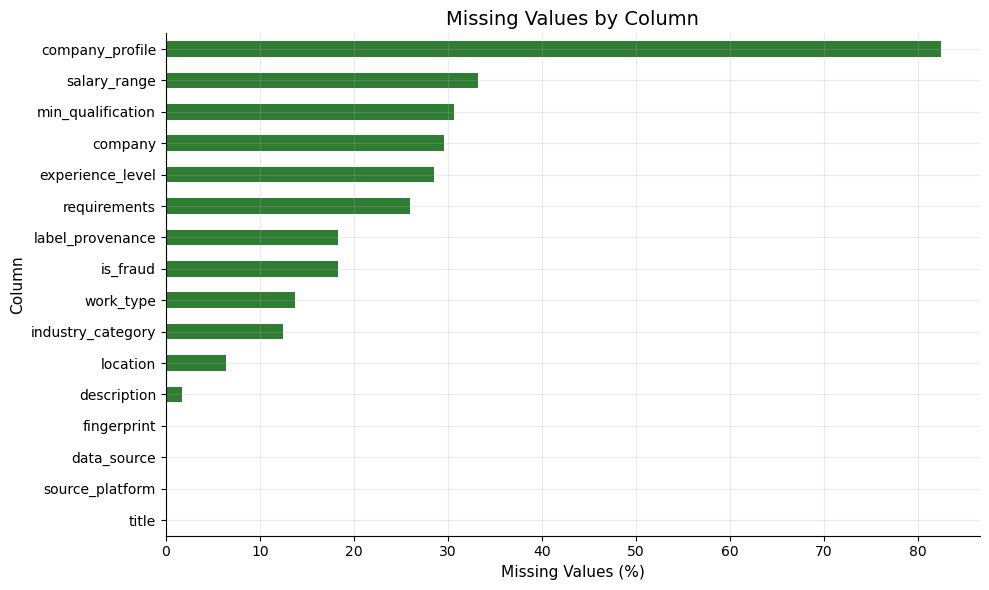

In [47]:
# Count missing values in each column
missing_percent = (eda_df.isna().mean() * 100).round(2)

display(missing_percent.sort_values(ascending=False).to_frame("missing_percent"))

missing_percent.sort_values().plot(kind="barh")
plt.title("Missing Values by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()


### 20.4 Labelled vs Unlabelled Job Postings

I am comparing labelled and unlabelled job postings to see how much of the dataset has a known fraud label. This helps me understand how much data is available for supervised modelling while keeping the unlabelled Kenyan job-board records separate.


,rows
is_fraud,
Labelled,58225
Unlabelled,13055


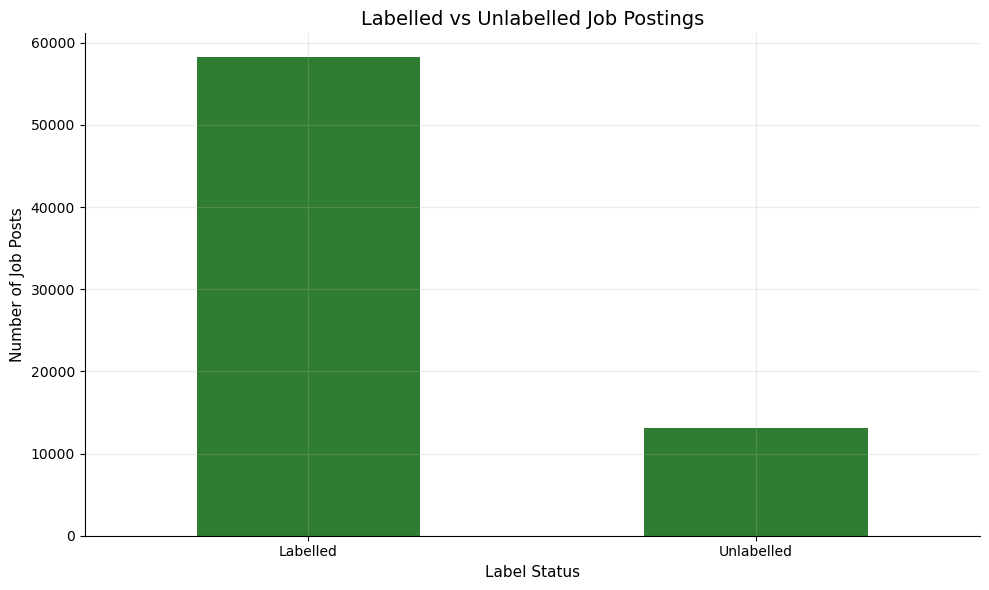

In [48]:
# Count labelled and unlabelled job postings
label_status = eda_df["is_fraud"].notna().map({True: "Labelled", False: "Unlabelled"})
label_status_counts = label_status.value_counts()

display(label_status_counts.to_frame("rows"))

label_status_counts.plot(kind="bar")
plt.title("Labelled vs Unlabelled Job Postings")
plt.xlabel("Label Status")
plt.ylabel("Number of Job Posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 20.5 Fraud Class Distribution

I am looking at the distribution of the fraud classes to see how many job postings are Legitimate, Suspicious, Fraudulent, and Unlabelled. This helps me understand the balance of the classes before moving on to modelling.


,rows
is_fraud,
Legitimate,40097
Unlabelled,13055
Suspicious,11902
Fraudulent,6226


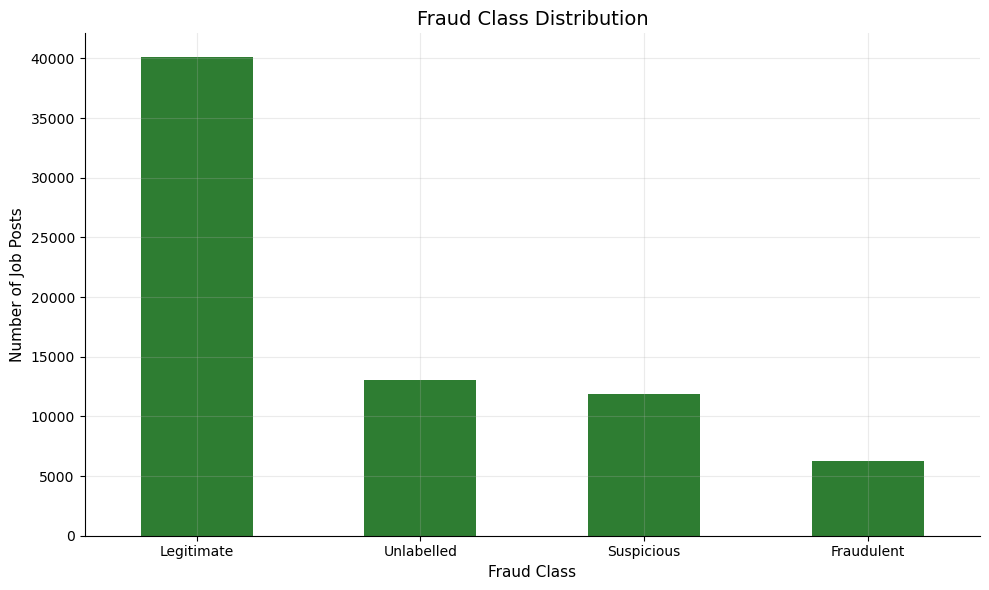

In [49]:
# Create readable labels without changing is_fraud
label_view = eda_df["is_fraud"].map(class_names).fillna("Unlabelled")
label_counts = label_view.value_counts()

display(label_counts.to_frame("rows"))

label_counts.plot(kind="bar")
plt.title("Fraud Class Distribution")
plt.xlabel("Fraud Class")
plt.ylabel("Number of Job Posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 20.6 Average Description Length

I am comparing the average description length for each labelled class. This helps me see whether the amount of text in a job posting differs between Legitimate, Suspicious, and Fraudulent posts.


,average_characters
Legitimate,631.29
Suspicious,259.19
Fraudulent,283.86


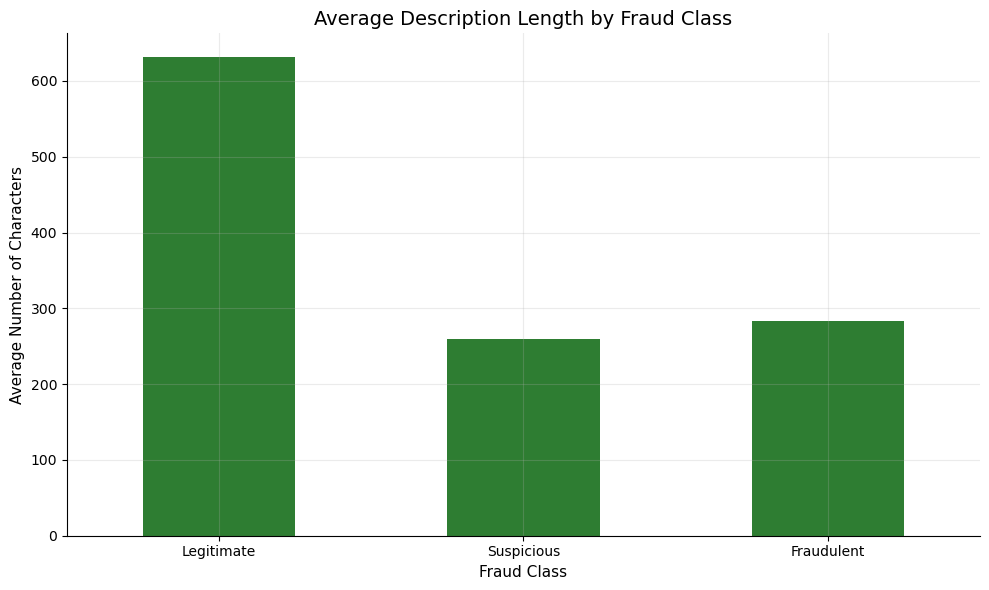

In [50]:
# Calculate the average description length for each labelled class
labelled = eda_df[eda_df["is_fraud"].notna()].copy()
labelled["description_length"] = labelled["description"].fillna("").str.len()

average_length = labelled.groupby("is_fraud")["description_length"].mean()
average_length.index = [class_names[i] for i in average_length.index]

display(average_length.round(2).to_frame("average_characters"))

average_length.plot(kind="bar")
plt.title("Average Description Length by Fraud Class")
plt.xlabel("Fraud Class")
plt.ylabel("Average Number of Characters")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 20.7 Original vs Synthetic Data

The final dataset contains both original and synthetic records. We use `data_source`.


,rows
data_source,
synthetic,42688
original,28592


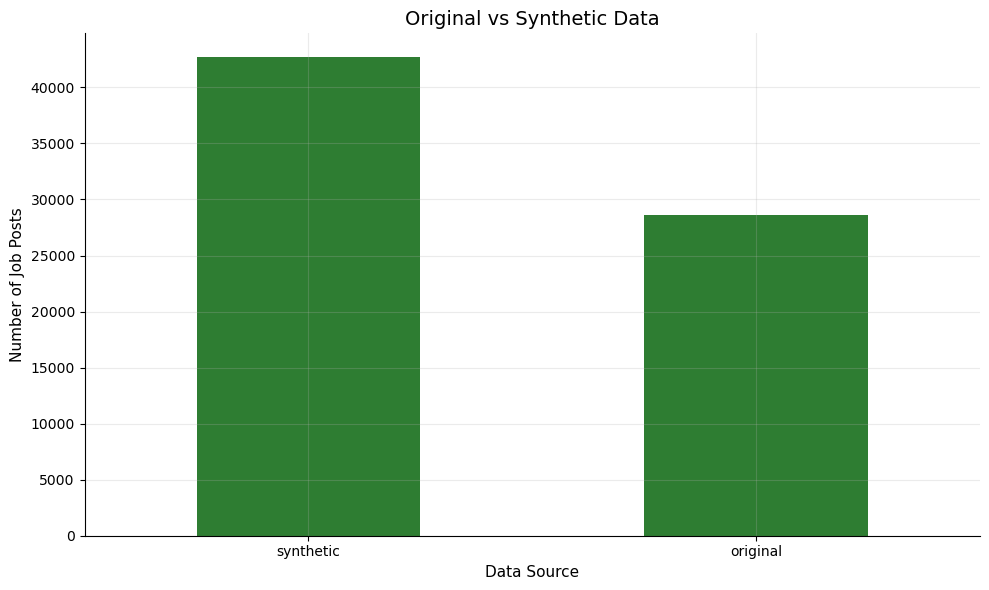

In [51]:
# Compare original and synthetic records
source_counts = eda_df["data_source"].value_counts()
display(source_counts.to_frame("rows"))

source_counts.plot(kind="bar")
plt.title("Original vs Synthetic Data")
plt.xlabel("Data Source")
plt.ylabel("Number of Job Posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 20.8 Label Source: Source Platform vs Class

This shows which platforms contribute each class and whether the Suspicious class exists in original data.


is_fraud,Fraudulent,Legitimate,Suspicious,Unlabelled
source_platform,,,,
BrighterMonday Kenya,0,0,0,1930
Corporate Staffing Kenya,0,0,0,3981
Fake Job Postings Dataset,667,14870,0,0
Fuzu Kenya,0,0,0,666
JobWeb Kenya,0,0,0,5249
PigiaMe Kenya,0,0,0,1229
Synthetic,5352,22654,11426,0
Synthetic Augmentation,207,2573,476,0


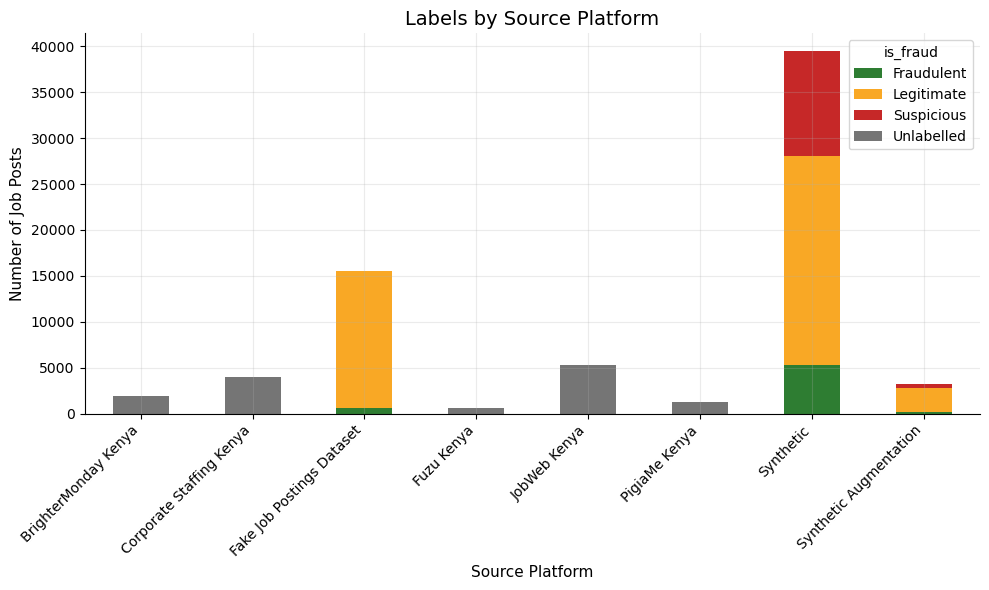

In [52]:
# Show where each label comes from
source_label = pd.crosstab(
    eda_df["source_platform"],
    label_view
)

display(source_label)

source_label.plot(kind="bar", stacked=True)
plt.title("Labels by Source Platform")
plt.xlabel("Source Platform")
plt.ylabel("Number of Job Posts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 20.9 Check the Suspicious Class

From the data preparation, EMSCAD only has Legitimate and Fraudulent labels, while the Suspicious class comes from the synthetic data. Here, I check this directly using the final `eda_df` because it helps the person doing modeling understand the quality and source of the labels.


In [53]:
# Check the source of the Suspicious class
suspicious = eda_df[eda_df["is_fraud"] == 1]

print("Suspicious rows:", len(suspicious))
print("Suspicious rows by data source:")
display(suspicious["data_source"].value_counts().to_frame("rows"))

print("\nEMSCAD labelled classes:")
emscad = eda_df[eda_df["source_platform"] == "Fake Job Postings Dataset"]
display(
    emscad["is_fraud"]
    .map(class_names)
    .value_counts()
    .to_frame("rows")
)


Suspicious rows: 11902
Suspicious rows by data source:


,rows
data_source,
synthetic,11902



EMSCAD labelled classes:


,rows
is_fraud,
Legitimate,14870
Fraudulent,667


### 20.10 Original vs Synthetic Class Proportions

I am comparing the percentages of each class in the original and synthetic data. This helps me see how the two types of data are made up and whether their class distributions are different.


In [54]:
# Compare the class composition within each data source
class_percent = pd.crosstab(
    eda_df["data_source"],
    label_view,
    normalize="index"
).mul(100).round(2)

display(class_percent)


is_fraud,Fraudulent,Legitimate,Suspicious,Unlabelled
data_source,,,,
original,2.33,52.01,0.00,45.66
synthetic,13.02,59.10,27.88,0.00


### 20.11 Missing Values by Label — Leakage Risk

The missing-value differences below are useful for diagnosing the dataset, but they should not be interpreted as fraud patterns. They are strongly tied to the source composition of the labelled data, so this analysis reveals a potential source-leakage problem.


In [55]:
# Compare missing values between the labelled classes.
# The resulting differences are examined as a potential source-leakage diagnostic.
labelled = eda_df[eda_df["is_fraud"].notna()].copy()

missing_by_label = pd.DataFrame({
    class_names[label]: labelled.loc[
        labelled["is_fraud"] == label
    ].isna().mean().mul(100)
    for label in class_names
})

display(missing_by_label.round(2))


,Legitimate,Suspicious,Fraudulent
title,0.00,0.0,0.00
company,37.09,0.0,10.71
company_profile,69.32,100.0,96.61
location,0.80,0.0,0.26
industry_category,16.80,4.0,6.67
work_type,7.42,0.0,2.52
salary_range,37.34,4.0,11.02
experience_level,19.86,4.0,8.50
min_qualification,23.55,4.0,8.74
description,0.00,0.0,0.02


### 20.12 Text Length Analysis — Leakage Risk

Because the project uses NLP, we test whether the labelled groups differ in the amount of text in their titles and descriptions.

This comparison must be interpreted as a source-leakage diagnostic rather than evidence that legitimate or fraudulent jobs naturally have different text lengths. In this dataset, EMSCAD descriptions are much longer on average than the synthetic descriptions, so description length can act as a proxy for data source.


In [56]:
# Create temporary text-length features for EDA only.
# Description length is treated as a potential source-leakage diagnostic,
# not as direct evidence of fraud.
text_eda = eda_df.copy()
text_eda["title_length"] = text_eda["title"].fillna("").str.len()
text_eda["description_length"] = text_eda["description"].fillna("").str.len()
text_eda["requirements_length"] = text_eda["requirements"].fillna("").str.len()

print("Average text length by class:")
display(
    text_eda[text_eda["is_fraud"].notna()]
    .groupby("is_fraud")[["title_length", "description_length", "requirements_length"]]
    .mean()
    .rename(index=class_names)
    .round(1)
)


Average text length by class:


,title_length,description_length,requirements_length
is_fraud,,,
Legitimate,20.4,631.3,263.0
Suspicious,15.8,259.2,45.6
Fraudulent,17.1,283.9,83.7


### 20.13 Description Length by Class

This chart checks how much the description-length distributions overlap.


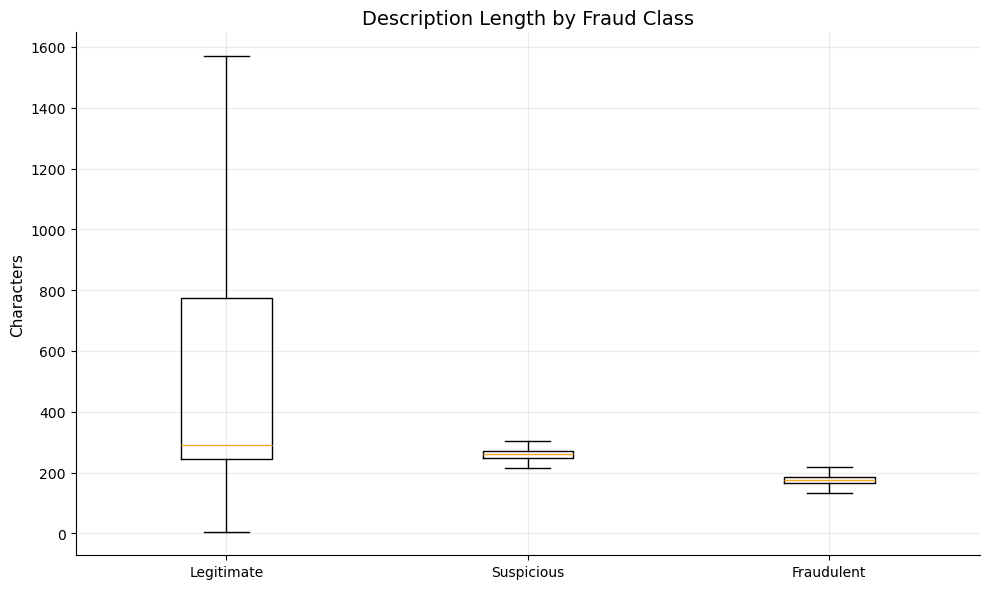

In [57]:
# Compare description length across labelled classes
# This is also a source-leakage diagnostic.
plot_data = [
    text_eda.loc[text_eda["is_fraud"] == label, "description_length"]
    for label in class_names
]

plt.boxplot(
    plot_data,
    tick_labels=[class_names[label] for label in class_names],
    showfliers=False
)
plt.title("Description Length by Fraud Class")
plt.ylabel("Characters")
plt.tight_layout()
plt.show()


### 20.14 Work Type by Class

Work type is a useful job characteristic, so we compare the most common categories with the three original labelled classes.


is_fraud,Fraudulent,Legitimate,Suspicious,Unlabelled
work_type,,,,
Full-time,4491,27918,8758,5957
Contract,1430,7256,2983,184
Part-time,136,1516,161,13
Temporary,2,229,0,0
Internship,0,0,0,218
Other,10,202,0,0


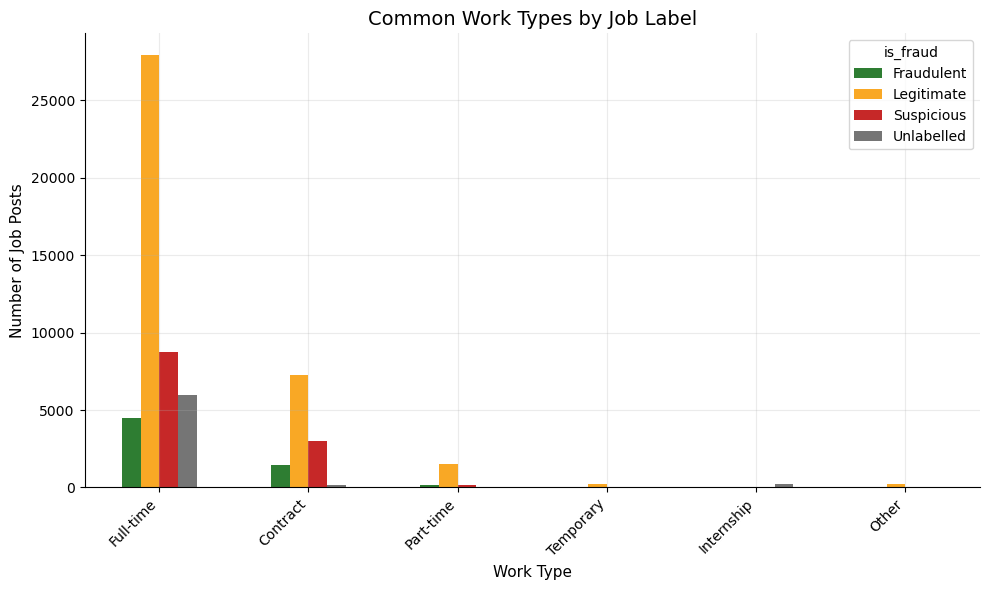

In [58]:
# Compare common work types with the fraud classes
work_class = pd.crosstab(
    eda_df["work_type"],
    label_view
)
top_work = eda_df["work_type"].value_counts().head(8).index

display(work_class.loc[top_work])

work_class.loc[top_work].plot(kind="bar")
plt.title("Common Work Types by Job Label")
plt.xlabel("Work Type")
plt.ylabel("Number of Job Posts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 20.15 Experience Level by Class

This checks whether the common experience levels are distributed differently across the labelled classes.


is_fraud,Fraudulent,Legitimate,Suspicious,Unlabelled
experience_level,,,,
Entry level,1519,7725,2763,525
No experience required,1326,5705,2915,0
3-5 years,1348,5604,2910,0
1-3 years,1308,5662,2838,0
Mid-Senior level,94,3518,0,0
Associate,28,2120,0,0
Not Applicable,44,963,0,0
Mid level,0,0,0,913


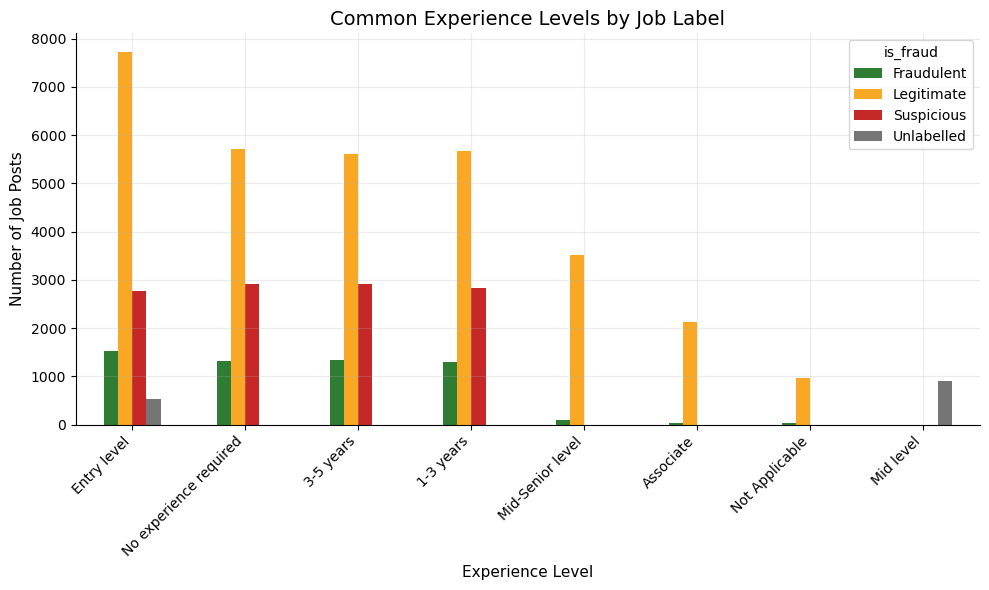

In [59]:
# Compare common experience levels with the fraud classes
experience_class = pd.crosstab(
    eda_df["experience_level"],
    label_view
)
top_experience = eda_df["experience_level"].value_counts().head(8).index

display(experience_class.loc[top_experience])

experience_class.loc[top_experience].plot(kind="bar")
plt.title("Common Experience Levels by Job Label")
plt.xlabel("Experience Level")
plt.ylabel("Number of Job Posts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 20.16 Top Locations

Location is useful for describing the dataset so, we show only the most common locations.


,rows
location,
Kenya,5248
Kisumu,2653
Nyeri,2598
Nakuru,2541
Eldoret,2534
Mombasa,2521
Machakos,2479
Thika,2466
Nairobi,2438


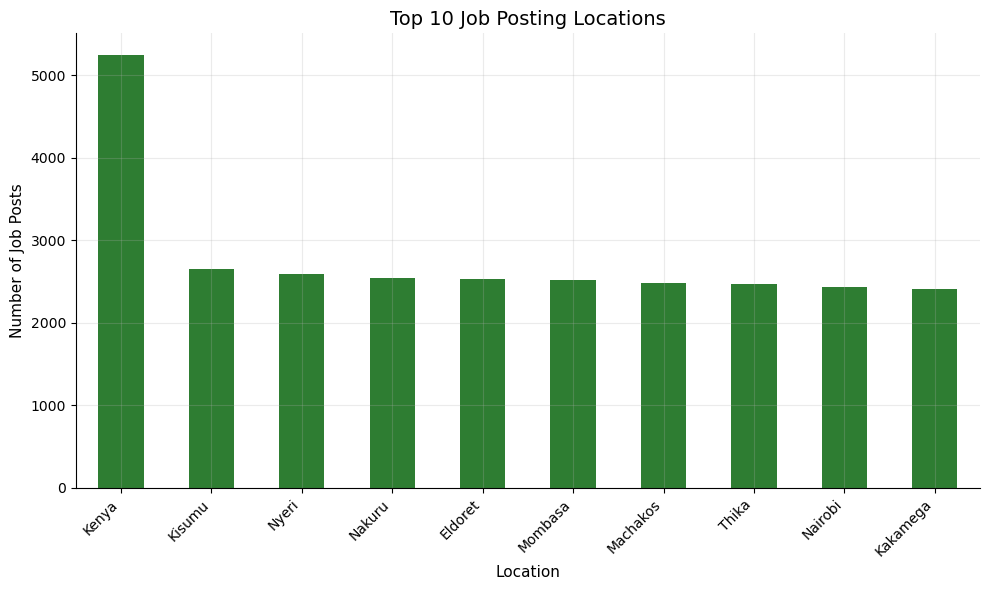

In [60]:
# Show the most common job locations
top_locations = eda_df["location"].value_counts().head(10)
display(top_locations.to_frame("rows"))

top_locations.plot(kind="bar")
plt.title("Top 10 Job Posting Locations")
plt.xlabel("Location")
plt.ylabel("Number of Job Posts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 20.17 Industry Category

Industry is checked as a descriptive variable and it should not be treated as proof of fraud by itself.


,rows
industry_category,
Telecommunications,4683
Retail,4618
Hospitality,4469
Construction,4455
Manufacturing,4451
Healthcare,4439
Insurance,4410
Banking & Finance,4371
Logistics,4367


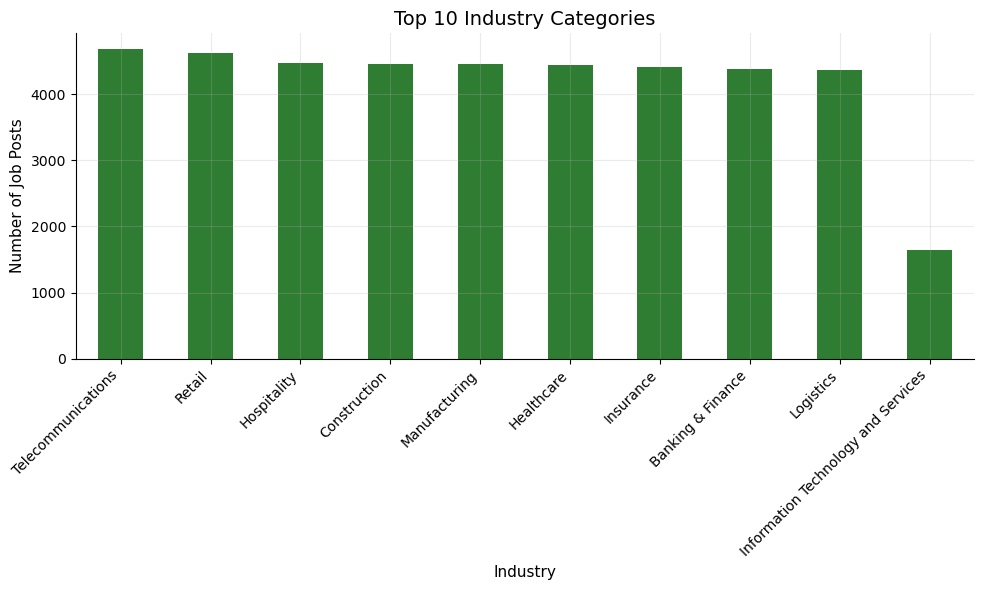

In [61]:
# Show the most common industry categories
top_industries = eda_df["industry_category"].value_counts().head(10)
display(top_industries.to_frame("rows"))

top_industries.plot(kind="bar")
plt.title("Top 10 Industry Categories")
plt.xlabel("Industry")
plt.ylabel("Number of Job Posts")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 20.18 Salary Availability — Leakage Risk

The shared `salary_range` field is text and has substantial missing values. We therefore check salary availability, rather than treating the raw text as a numerical variable at this stage.

The class differences below are a potential source-leakage signal, not evidence that scam postings naturally advertise salaries more often. The synthetic labelled records fill this field more consistently than some original sources, so salary availability can partially identify the source used to create the row.


In [62]:
# Check whether a salary range is provided.
# Salary availability is treated as a potential source-leakage diagnostic.
salary_view = pd.crosstab(
    label_view,
    eda_df["salary_range"].notna(),
    normalize="index"
).mul(100).round(2)

salary_view.columns = ["Salary missing", "Salary provided"]
display(salary_view)


,Salary missing,Salary provided
is_fraud,,
Fraudulent,11.02,88.98
Legitimate,37.34,62.66
Suspicious,4.00,96.00
Unlabelled,57.83,42.17


### 20.19 Temporary Binary Modelling View

For some later modelling-style checks, classes 1 and 2 can be grouped. We keep this in a separate dataframe so the original `is_fraud` column remains unchanged.


In [63]:
# Create a separate binary view without changing eda_df
binary_eda = eda_df.copy()
binary_eda["fraud_group"] = binary_eda["is_fraud"].map({
    0: "Legitimate",
    1: "Potentially Fraudulent",
    2: "Potentially Fraudulent"
}).fillna("Unlabelled")

display(binary_eda["fraud_group"].value_counts().to_frame("rows"))


,rows
fraud_group,
Legitimate,40097
Potentially Fraudulent,18128
Unlabelled,13055


In [64]:
# Confirm that the original fraud labels were not changed
assert "fraud_group" not in eda_df.columns
print("is_fraud was kept unchanged in eda_df.")


is_fraud was kept unchanged in eda_df.


### 20.20 Leakage Risks Identified

The three patterns above are important EDA findings because they track **data source rather than fraud**.

- **`company_profile` missingness:** `company_profile` exists only for EMSCAD rows. EMSCAD contains Legitimate and Fraudulent rows but no Suspicious rows, so the presence or absence of this field can reveal which source a row came from and indirectly reveal the class composition.
- **Salary and requirements missingness:** `salary_range` and `requirements` have very different missingness rates across the labelled classes because the classes come from different source groups. The synthetic generation process fills these fields more consistently, making missingness a source proxy rather than a reliable fraud signal.
- **Description length:** Legitimate descriptions are much longer on average than Suspicious and Fraudulent descriptions in this dataset. This primarily reflects EMSCAD versus synthetic description lengths, not an honest-versus-fraudulent writing pattern. The same source-driven signal was also responsible for the earlier contaminated high-performance result in the project.

**Modelling decision:** `company_profile` should be excluded from modelling features. Missing-field indicators such as `company_profile_missing`, `salary_range_missing`, and `requirements_missing` should also be excluded because they can encode the data source. Description-length features should likewise be treated as leakage-prone unless they are re-evaluated with a source-aware validation strategy.

The provenance fields such as `source_platform` and `data_source` should remain available for auditing, EDA, and source-aware validation, but should not be supplied to the classifier as predictive inputs.


### 20.21 Text Content Analysis — Word and Bigram Frequency

Because the modelling approach is NLP/TF-IDF, the EDA should inspect the language contained in the postings rather than only their structured columns. This section compares the most frequent words and two-word phrases (bigrams) across the labelled classes.

The analysis is exploratory: frequent terms can reveal useful vocabulary, but they are not treated as proof of fraud. The text is built from `title`, `description`, and `requirements`, with common English stopwords removed.

In [65]:
# Prepare the posting text used for vocabulary analysis.
# We keep the original dataframe unchanged and use only labelled rows for class comparisons.
import re
from collections import Counter

TEXT_COLUMNS = ["title", "description", "requirements"]
STOPWORDS = {
    "a", "about", "after", "all", "also", "an", "and", "any", "are", "as", "at", "be",
    "been", "before", "being", "between", "both", "but", "by", "can", "could", "did",
    "do", "does", "doing", "down", "during", "each", "for", "from", "further", "had",
    "has", "have", "having", "he", "her", "here", "hers", "herself", "him", "himself", "his",
    "how", "i", "if", "in", "into", "is", "it", "its", "itself", "just", "me", "more", "most",
    "my", "myself", "no", "nor", "not", "of", "off", "on", "once", "only", "or", "other", "our",
    "ours", "ourselves", "out", "over", "own", "same", "she", "should", "so", "some", "such",
    "than", "that", "the", "their", "theirs", "them", "themselves", "then", "there", "these",
    "they", "this", "those", "through", "to", "too", "under", "until", "up", "very", "was", "we",
    "were", "what", "when", "where", "which", "while", "who", "whom", "why", "will", "with", "would",
    "you", "your", "yours", "yourself", "yourselves"
}

def combine_posting_text(frame):
    return (
        frame[TEXT_COLUMNS]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

def tokenize(text):
    words = re.findall(r"[a-zA-Z][a-zA-Z'-]{2,}", text.lower())
    return [word for word in words if word not in STOPWORDS]

labelled_text = eda_df[eda_df["is_fraud"].notna()].copy()
labelled_text["posting_text"] = combine_posting_text(labelled_text)

word_counts_by_class = {}
bigram_counts_by_class = {}

for label in class_names:
    class_text = labelled_text.loc[labelled_text["is_fraud"] == label, "posting_text"]
    word_counter = Counter()
    bigram_counter = Counter()

    for text in class_text:
        tokens = tokenize(text)
        word_counter.update(tokens)
        bigram_counter.update(zip(tokens, tokens[1:]))

    word_counts_by_class[class_names[label]] = word_counter
    bigram_counts_by_class[class_names[label]] = bigram_counter

print("Top 15 words by labelled class:")
for class_label in [class_names[label] for label in class_names]:
    top_words = pd.DataFrame(
        word_counts_by_class[class_label].most_common(15),
        columns=["word", "frequency"]
    )
    print(f"\n{class_label}")
    display(top_words)

print("Top 15 bigrams by labelled class:")
for class_label in [class_names[label] for label in class_names]:
    top_bigrams = pd.DataFrame(
        [(f"{a} {b}", n) for (a, b), n in bigram_counts_by_class[class_label].most_common(15)],
        columns=["bigram", "frequency"]
    )
    print(f"\n{class_label}")
    display(top_bigrams)


Top 15 words by labelled class:

Legitimate


,word,frequency
0,team,55342
1,required,40717
2,experience,40023
3,join,27480
4,preferred,25569
5,seeking,24917
6,years,23723
7,qualified,23481
8,work,21993
9,company,19983



Suspicious


,word,frequency
0,required,16315
1,looking,11597
2,work,11426
3,preferred,11426
4,years,5973
5,ltd,5920
6,certificate,5757
7,group,5708
8,team,4657
9,assistant,4602



Fraudulent


...

,bigram,frequency
0,join team,25039
1,seeking qualified,22687
2,required years,11572
3,years preferred,11433
4,certificate required,11310
5,line company,10109
6,limited seeking,6896
7,team members,6208
8,experience required,6168
9,years experience,6141



Suspicious


,bigram,frequency
0,required years,5788
1,years preferred,5788
2,certificate required,5757
3,ltd looking,5718
4,group looking,5708
5,line company,3810
6,experience required,2936
7,kcse certificate,2893
8,required experience,2847
9,required preferred,2847



Fraudulent


,bigram,frequency
0,processing fee,4678
1,experience needed,3636
2,needed anyone,3631
3,anyone apply,3631
4,required immediate,3559
5,qualifications required,3549
6,immediate hire,3549
7,must willing,3535
8,willing pay,3524
9,pay processing,3524


### 20.21.1 Vocabulary Overlap: Original vs Synthetic

Vocabulary overlap is checked because synthetic postings may use a different language distribution from the real/original postings. Low overlap would indicate distribution shift and would be a reason to validate synthetic data carefully before relying on it for training.

The comparison is made after the same text normalization and stopword removal used above. The Jaccard score is the size of the shared vocabulary divided by the union of both vocabularies.

In [66]:
# Measure vocabulary overlap between original and synthetic postings.
all_text = eda_df.copy()
all_text["posting_text"] = combine_posting_text(all_text)

vocab_sets = {}
for source_name in ["original", "synthetic"]:
    tokens = []
    for text in all_text.loc[all_text["data_source"] == source_name, "posting_text"]:
        tokens.extend(tokenize(text))
    vocab_sets[source_name] = set(tokens)

original_vocab = vocab_sets["original"]
synthetic_vocab = vocab_sets["synthetic"]
shared_vocab = original_vocab & synthetic_vocab
union_vocab = original_vocab | synthetic_vocab

vocab_overlap_summary = pd.DataFrame({
    "metric": [
        "Original unique words",
        "Synthetic unique words",
        "Shared words",
        "Original-only words",
        "Synthetic-only words",
        "Jaccard overlap",
        "Original vocabulary covered by synthetic",
        "Synthetic vocabulary covered by original",
    ],
    "value": [
        len(original_vocab),
        len(synthetic_vocab),
        len(shared_vocab),
        len(original_vocab - synthetic_vocab),
        len(synthetic_vocab - original_vocab),
        round(len(shared_vocab) / len(union_vocab) * 100, 2) if union_vocab else 0.0,
        round(len(shared_vocab) / len(original_vocab) * 100, 2) if original_vocab else 0.0,
        round(len(shared_vocab) / len(synthetic_vocab) * 100, 2) if synthetic_vocab else 0.0,
    ]
})

display(vocab_overlap_summary)

# EMSCAD-versus-synthetic is the most direct source comparison for the labelled classes.
emscad_text = all_text.loc[
    all_text["source_platform"] == EMSCAD_PLATFORM, "posting_text"
]
emscad_vocab = set(token for text in emscad_text for token in tokenize(text))
emscad_shared = emscad_vocab & synthetic_vocab
emscad_union = emscad_vocab | synthetic_vocab

emscad_overlap = pd.DataFrame({
    "metric": [
        "EMSCAD unique words",
        "Synthetic unique words",
        "Shared words",
        "Jaccard overlap",
        "EMSCAD vocabulary covered by synthetic",
        "Synthetic vocabulary covered by EMSCAD",
    ],
    "value": [
        len(emscad_vocab),
        len(synthetic_vocab),
        len(emscad_shared),
        round(len(emscad_shared) / len(emscad_union) * 100, 2) if emscad_union else 0.0,
        round(len(emscad_shared) / len(emscad_vocab) * 100, 2) if emscad_vocab else 0.0,
        round(len(emscad_shared) / len(synthetic_vocab) * 100, 2) if synthetic_vocab else 0.0,
    ]
})

print("EMSCAD vs synthetic vocabulary overlap:")
display(emscad_overlap)


,metric,value
0,Original unique words,115583.00
1,Synthetic unique words,344.00
2,Shared words,339.00
3,Original-only words,115244.00
4,Synthetic-only words,5.00
5,Jaccard overlap,0.29
6,Original vocabulary covered by synthetic,0.29
7,Synthetic vocabulary covered by original,98.55


EMSCAD vs synthetic vocabulary overlap:


,metric,value
0,EMSCAD unique words,95808.00
1,Synthetic unique words,344.00
2,Shared words,312.00
3,Jaccard overlap,0.33
4,EMSCAD vocabulary covered by synthetic,0.33
5,Synthetic vocabulary covered by EMSCAD,90.70


### 20.22 Company and Employer Name Analysis

The deployed design includes employer verification, so company names deserve a separate EDA check. We show the most frequent company names among labelled rows and identify names that appear under more than one fraud label.

A company appearing under multiple labels should not automatically be treated as evidence of fraud or legitimacy; it is a signal to review the underlying records and to avoid allowing the model to memorize employer names.

In [67]:
# Normalize company names for frequency and cross-label checks.
company_view = eda_df[eda_df["is_fraud"].notna()].copy()
company_view["company_normalized"] = (
    company_view["company"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
company_view = company_view[company_view["company_normalized"] != ""].copy()
company_view["fraud_class"] = company_view["is_fraud"].map(class_names)

company_counts = company_view["company_normalized"].value_counts().head(15)
company_frequency = company_counts.rename_axis("company").reset_index(name="rows")
print("Top 15 company names among labelled postings:")
display(company_frequency)

company_label_table = pd.crosstab(
    company_view["company_normalized"],
    company_view["fraud_class"]
)

# Make the class columns predictable when a class is absent.
for class_label in [class_names[label] for label in class_names]:
    if class_label not in company_label_table.columns:
        company_label_table[class_label] = 0
company_label_table = company_label_table[[class_names[label] for label in class_names]]

company_label_table["label_count"] = (company_label_table > 0).sum(axis=1)
multi_label_companies = company_label_table[company_label_table["label_count"] > 1].copy()

print("Companies appearing under more than one fraud label:")
if multi_label_companies.empty:
    print("No labelled company name appears under more than one fraud label.")
else:
    display(multi_label_companies.sort_values("label_count", ascending=False))


Top 15 company names among labelled postings:


,company,rows
0,co-operative bank of kenya,1047
1,kcb bank kenya,1026
2,nairobi hospital,1010
3,bamburi cement,1007
4,kengen,1004
5,equity bank kenya,993
6,britam holdings,992
7,kenya airways,988
8,jubilee insurance,987
9,kakuzi plc,981


Companies appearing under more than one fraud label:


fraud_class,Legitimate,Suspicious,Fraudulent,label_count
company_normalized,,,,
not disclosed,0,476,207,2


### 20.23 Description Length Distribution

The earlier mean comparison and boxplot show differences in description length, but averages alone can hide substantial overlap. A distribution plot makes the shape and overlap between Legitimate, Suspicious, and Fraudulent postings clearer.

Because description length was already identified as a possible source-leakage signal, this chart is interpreted as a diagnostic of dataset composition rather than as evidence that one class naturally writes longer or shorter job advertisements.

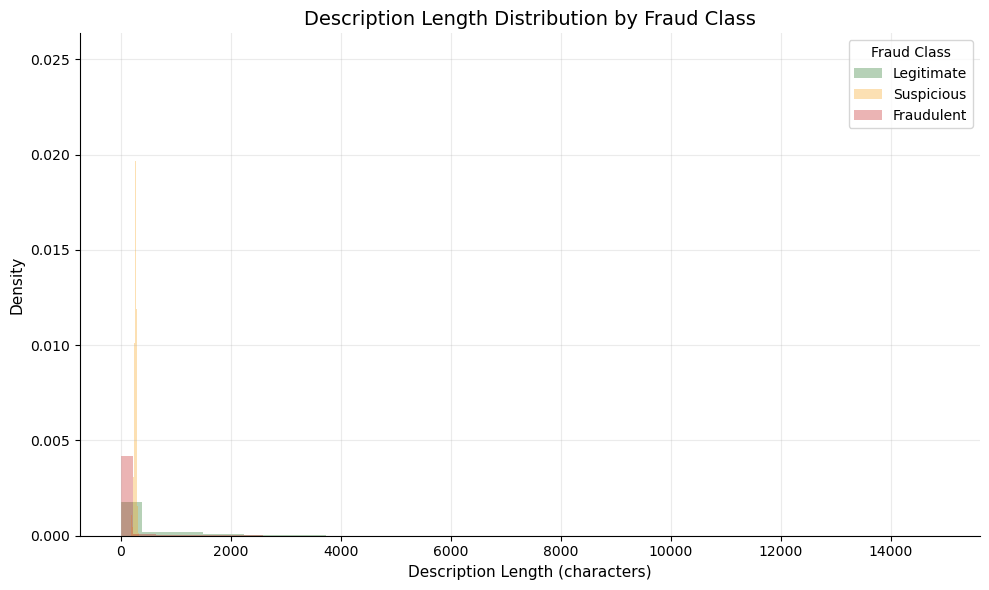

,count,mean,median,q1,q3
is_fraud,,,,,
Legitimate,40097,631.3,290.0,245,775
Suspicious,11902,259.2,260.0,249,271
Fraudulent,6226,283.9,176.0,164,186


In [68]:
# Plot the full description-length distribution for each labelled class.
distribution_df = text_eda[text_eda["is_fraud"].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 6))
for label in class_names:
    class_label = class_names[label]
    values = distribution_df.loc[
        distribution_df["is_fraud"] == label, "description_length"
    ]
    ax.hist(
        values,
        bins=40,
        density=True,
        alpha=0.35,
        label=class_label,
        color=CLASS_COLORS[class_label],
    )

ax.set_title("Description Length Distribution by Fraud Class")
ax.set_xlabel("Description Length (characters)")
ax.set_ylabel("Density")
ax.legend(title="Fraud Class")
fig.tight_layout()
plt.show()

# Summary statistics make the amount of overlap easier to interpret alongside the plot.
description_distribution_summary = (
    distribution_df.groupby("is_fraud")["description_length"]
    .agg(
        count="size",
        mean="mean",
        median="median",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
    )
    .rename(index=class_names)
    .round(1)
)

display(description_distribution_summary)


## Part 21: EDA Findings and Decisions

The points below record the main questions tested in this EDA and the decisions taken from the structure of the dataset.

### Main findings to document

- `eda_df` contains the complete cleaned dataset used for EDA.
- The dataset contains both original and synthetic records; `data_source` is used to keep that provenance visible.
- `is_fraud` remains a three-class label: 0 = Legitimate, 1 = Suspicious, 2 = Fraudulent.
- The 13,055 Kenyan job-board records with no verified fraud label remain unlabelled; they are not treated as Legitimate.
- EMSCAD contains only Legitimate and Fraudulent labels. The Suspicious class is therefore represented by synthetic data.
- Text length, work type, experience level, location, industry and salary availability were explored as descriptive EDA variables.
- Three source-leakage patterns were identified: `company_profile` presence, missing-field rates for `salary_range`/`requirements`, and description length.

### Analyses not used as main modelling evidence

- **Large correlation heatmap:** not used as a main EDA result because most variables are text or categorical rather than continuous numeric variables.
- **Raw salary as a numeric feature:** not used in this EDA because `salary_range` is stored as text and has substantial missingness. Salary availability was checked instead, but its strong class difference was treated as a potential source-leakage pattern rather than evidence of fraud.
- **Location as proof of fraud:** not used as a direct fraud conclusion because location formats and source coverage differ across the original datasets.

### Important modelling consideration

The Suspicious class is synthetic-only in the labelled data. This means any pattern learned for that class should be interpreted carefully and tested against the real-world Kenyan job-board data during later validation.

The modelling plan should exclude `company_profile` and missing-field indicators that can identify the data source. Description-length features should also be treated as leakage-prone unless they are validated using source-aware splits.

The original `is_fraud` column remains unchanged throughout this EDA.


### 21.1 Action Summary Table

| Area / column | EDA finding | Modelling implication |
|---|---|---|
| `company_profile` | Presence is tied to EMSCAD source composition and can reveal provenance. | Exclude from predictive features. Keep for EDA/auditing only. |
| `salary_range` / `requirements` missingness | Missingness differs by source/class and can act as a source proxy. | Exclude missing-field indicators from predictive features unless revalidated with source-aware splits. |
| Description length | Class means differ largely because EMSCAD and synthetic descriptions differ in length. | Treat description-length features as leakage-prone and validate with source-aware splits. |
| Word / bigram frequency | Different classes use different vocabulary and phrases. | Use for exploratory NLP understanding and later feature interpretation, not as standalone fraud rules. |
| Original vs synthetic vocabulary | Vocabulary overlap measures whether synthetic text resembles the original data distribution. | Low overlap is evidence of distribution shift and supports source-aware validation before synthetic data is relied upon for training. |
| Company names | Some employer names may repeat, and cross-label company names need review. | Do not allow the classifier to simply memorize employer names; separate employer verification from text classification. |
| Description-length distribution | The full distributions show whether class differences overlap or separate. | Use the distribution, not only the mean, when judging whether length is a plausible modelling feature. |
